# Importación de Librerías y Configuración

In [1]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import seaborn as sns
import warnings

# Suprimir avisos de deprecación entre Seaborn y Matplotlib
warnings.filterwarnings('ignore')

# Configuración visual global para EDA
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Carga de Archivos CSV

In [2]:
df_catalogo_productos = pd.read_csv(r"D:\Machine Learning\Proyectos\Bonsai_Corp\data\catalogo_productos.csv")
df_especificaciones_cajas = pd.read_csv(r"D:\Machine Learning\Proyectos\Bonsai_Corp\data\especificaciones_cajas.csv")
df_operaciones_planta = pd.read_csv(r"D:\Machine Learning\Proyectos\Bonsai_Corp\data\operaciones_planta.csv")
df_procuremente_cajas = pd.read_csv(r"D:\Machine Learning\Proyectos\Bonsai_Corp\data\procurement_cajas.csv")

print("[OK] Carga de archivos completada exitosamente:")
print(f" - Catálogo de productos: {df_catalogo_productos.shape}")
print(f" - Especificaciones de cajas: {df_especificaciones_cajas.shape}")
print(f" - Operaciones de planta: {df_operaciones_planta.shape}")
print(f" - Procurement de cajas: {df_procuremente_cajas.shape}")

[OK] Carga de archivos completada exitosamente:
 - Catálogo de productos: (427, 12)
 - Especificaciones de cajas: (204, 16)
 - Operaciones de planta: (427, 29)
 - Procurement de cajas: (204, 19)


# Limpieza y Preprocesamiento Integrado de Datos

## 0. Análisis Exploratorio Inicial
Inspección general de la estructura de los DataFrames mediante `.info()`, `.describe()`, y análisis de valores nulos y duplicados para evaluar la calidad de los datos crudos.

In [3]:
dataframes = {
    'Catálogo de Productos': df_catalogo_productos,
    'Especificaciones de Cajas': df_especificaciones_cajas,
    'Operaciones Planta': df_operaciones_planta,
    'Procurement Cajas': df_procuremente_cajas
}

for name, df in dataframes.items():
    print(f"\n{'='*60}")
    print(f"--- {name.upper()} ---")
    print(f"{'='*60}")
    
    print("\n1. INFORMACIÓN GENERAL:")
    df.info()
    
    print("\n2. VALORES NULOS:")
    nulos = df.isnull().sum()
    if nulos.sum() > 0:
        print(nulos[nulos > 0])
    else:
        print("Sin valores nulos.")
        
    print("\n3. DUPLICADOS EXACTOS:")
    print(df.duplicated().sum())
    
    print("\n4. ESTADÍSTICAS DESCRIPTIVAS:")
    display(df.describe(include='all'))



--- CATÁLOGO DE PRODUCTOS ---

1. INFORMACIÓN GENERAL:
<class 'pandas.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   codigo_producto       427 non-null    str    
 1   descripcion_producto  427 non-null    str    
 2   ingrediente_forma     427 non-null    str    
 3   tipo_proyecto         427 non-null    str    
 4   subcategoria          427 non-null    str    
 5   categoria             427 non-null    str    
 6   tamaño_corte          427 non-null    str    
 7   peso_neto_caja        427 non-null    float64
 8   tamaño_paquete        427 non-null    str    
 9   cantidad_paquetes     405 non-null    float64
 10  peso_neto_paquete     398 non-null    float64
 11  caja_tipo_id          427 non-null    str    
dtypes: float64(3), str(9)
memory usage: 40.2 KB

2. VALORES NULOS:
cantidad_paquetes    22
peso_neto_paquete    29
dtype: int64

3. DUP

,codigo_producto,descripcion_producto,ingrediente_forma,tipo_proyecto,subcategoria,categoria,tamaño_corte,peso_neto_caja,tamaño_paquete,cantidad_paquetes,peso_neto_paquete,caja_tipo_id
count,427,427,427,427,427,427,427,427.000000,427,405.000000,398.000000,427
unique,427,376,23,3,18,5,5,NaN,50,NaN,NaN,204
top,BR0001,Dippers de brocoli - clasico - Caja de 5 packs...,Bastones rectos de brocoli,Estacional,Bastones clasicos - Sigilo,Bastones clasicos,Forma,NaN,"5 X 2,5 KG",NaN,NaN,fa8da38322149b23e14a120e71d38975
freq,1,5,220,220,218,365,208,NaN,212,NaN,NaN,10
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.882904,NaN,7.213580,1.851131,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.564723,NaN,3.579594,0.848383,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.500000,NaN,0.750000,0.500000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.750000,NaN,5.000000,1.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.500000,NaN,5.000000,2.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.500000,NaN,11.000000,2.500000,NaN



--- ESPECIFICACIONES DE CAJAS ---

1. INFORMACIÓN GENERAL:
<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   caja_tipo_id          204 non-null    str    
 1   caja_grosor_mm        204 non-null    str    
 2   caja_interior_largo   204 non-null    float64
 3   caja_interior_ancho   204 non-null    float64
 4   caja_interior_alto    204 non-null    float64
 5   caja_exterior_largo   204 non-null    float64
 6   caja_exterior_ancho   204 non-null    float64
 7   caja_exterior_alto    204 non-null    float64
 8   pallet_alto           204 non-null    int64  
 9   pallet_ancho          204 non-null    int64  
 10  pallet_largo          204 non-null    int64  
 11  cantidad_cajas_alto   204 non-null    float64
 12  cantidad_cajas_largo  204 non-null    float64
 13  cantidad_cajas_ancho  204 non-null    float64
 14  cantidad_cajas_total  173

,caja_tipo_id,caja_grosor_mm,caja_interior_largo,caja_interior_ancho,caja_interior_alto,caja_exterior_largo,caja_exterior_ancho,caja_exterior_alto,pallet_alto,pallet_ancho,pallet_largo,cantidad_cajas_alto,cantidad_cajas_largo,cantidad_cajas_ancho,cantidad_cajas_total,utilizacion
count,204,204,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.0,204.0,204.0,204.000000,204.0,204.000000,173.000000,204.000000
unique,204,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,02cf77de65b70dd77905e2e33d78478f,4.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,387.240196,275.480392,226.745098,394.776471,283.083333,234.348039,1800.0,800.0,1200.0,7.544118,2.0,3.848039,58.809249,0.836936
std,NaN,NaN,5.564326,19.028747,49.432481,4.041879,19.025001,49.250875,0.0,0.0,0.0,1.694097,0.0,0.398823,15.051598,0.084827
min,NaN,NaN,375.000000,182.000000,138.000000,384.200000,191.200000,143.400000,1800.0,800.0,1200.0,4.000000,2.0,3.000000,30.000000,0.641312
25%,NaN,NaN,383.000000,255.000000,187.250000,391.200000,260.400000,194.550000,1800.0,800.0,1200.0,6.000000,2.0,4.000000,48.000000,0.771050
50%,NaN,NaN,386.000000,286.000000,221.500000,394.200000,294.200000,228.800000,1800.0,800.0,1200.0,7.000000,2.0,4.000000,56.000000,0.842435
75%,NaN,NaN,393.000000,288.000000,260.000000,398.400000,296.200000,265.750000,1800.0,800.0,1200.0,9.000000,2.0,4.000000,66.000000,0.904917



--- OPERACIONES PLANTA ---

1. INFORMACIÓN GENERAL:
<class 'pandas.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   codigo_producto                              427 non-null    str    
 1   volumen_producto_canal_servicios_comida      427 non-null    int64  
 2   volumen_producto_canal_minorista             427 non-null    int64  
 3   volumen_producto_canal_cadenas_corporativas  427 non-null    int64  
 4   volumen_producto_canal_otros                 427 non-null    int64  
 5   volumen_producto_total                       427 non-null    int64  
 6   volumen_producto_planta_buenos_aires         427 non-null    int64  
 7   volumen_producto_planta_curitiba             427 non-null    int64  
 8   volumen_producto_planta_santiago             427 non-null    int64  
 9   volumen_producto_planta_monterrey 

,codigo_producto,volumen_producto_canal_servicios_comida,volumen_producto_canal_minorista,volumen_producto_canal_cadenas_corporativas,volumen_producto_canal_otros,volumen_producto_total,volumen_producto_planta_buenos_aires,volumen_producto_planta_curitiba,volumen_producto_planta_santiago,volumen_producto_planta_monterrey,...,costo_total_planta_santiago,costo_total_planta_monterrey,costo_total_planta_bakersfield,costo_pallets_planta_buenos_aires,costo_pallets_planta_curitiba,costo_pallets_planta_santiago,costo_pallets_planta_monterrey,costo_pallets_planta_bakersfield,costo_pallets_total,costo_total
count,427,4.270000e+02,427.000000,4.270000e+02,427.000000,4.270000e+02,4.270000e+02,4.270000e+02,4.270000e+02,4.270000e+02,...,427.000000,427.000000,427.000000,4.270000e+02,4.270000e+02,4.270000e+02,4.270000e+02,4.270000e+02,4.270000e+02,4.270000e+02
unique,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,BR0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,8.547168e+04,20426.107728,3.891242e+04,1374.601874,1.461848e+05,2.083492e+04,5.310773e+04,3.581282e+04,1.651209e+04,...,17553.650972,7673.141780,9750.451511,6.084660e+04,1.500808e+05,1.067701e+05,4.283993e+04,5.882740e+04,4.193649e+05,7.064706e+04
std,NaN,2.543677e+05,68374.444080,1.617667e+05,8529.339786,2.969869e+05,1.197490e+05,1.663282e+05,1.170576e+05,9.869302e+04,...,53760.044089,42298.506534,37135.695825,4.154748e+05,5.056656e+05,3.880489e+05,2.626754e+05,2.633024e+05,9.064421e+05,1.312743e+05
min,NaN,0.000000e+00,0.000000,0.000000e+00,0.000000,2.140000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+02,1.197950e+02
25%,NaN,0.000000e+00,0.000000,0.000000e+00,0.000000,1.736750e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.635000e+04,1.011163e+04
50%,NaN,7.783000e+03,0.000000,0.000000e+00,0.000000,4.300300e+04,0.000000e+00,7.600000e+01,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000e+00,3.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.144500e+05,2.480699e+04
75%,NaN,4.790800e+04,11831.000000,1.295000e+02,0.000000,1.109080e+05,2.862500e+03,3.127650e+04,1.296300e+04,0.000000e+00,...,8244.307500,0.000000,0.000000,6.225000e+03,8.475000e+04,3.502500e+04,0.000000e+00,0.000000e+00,2.981250e+05,5.603775e+04



--- PROCUREMENT CAJAS ---

1. INFORMACIÓN GENERAL:
<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   caja_tipo_id                        204 non-null    str    
 1   volumen_tipo_planta_buenos_aires    204 non-null    int64  
 2   volumen_tipo_planta_curitiba        204 non-null    int64  
 3   volumen_tipo_planta_santiago        204 non-null    int64  
 4   volumen_tipo_planta_monterrey       204 non-null    int64  
 5   volumen_tipo_planta_bakersfield     204 non-null    int64  
 6   costo_unitario_base                 204 non-null    float64
 7   costo_total_base                    204 non-null    float64
 8   costo_unitario_planta_buenos_aires  204 non-null    str    
 9   costo_unitario_planta_curitiba      204 non-null    str    
 10  costo_unitario_planta_santiago      204 non-null    str    
 11  cost

,caja_tipo_id,volumen_tipo_planta_buenos_aires,volumen_tipo_planta_curitiba,volumen_tipo_planta_santiago,volumen_tipo_planta_monterrey,volumen_tipo_planta_bakersfield,costo_unitario_base,costo_total_base,costo_unitario_planta_buenos_aires,costo_unitario_planta_curitiba,costo_unitario_planta_santiago,costo_unitario_planta_monterrey,costo_unitario_planta_bakersfield,descuento_planta_buenos_aires,descuento_planta_curitiba,descuento_planta_santiago,descuento_planta_monterrey,descuento_planta_bakersfield,costo_por_pallet
count,204,2.040000e+02,2.040000e+02,2.040000e+02,2.040000e+02,2.040000e+02,204.000000,2.040000e+02,204,204,204,204,204,204,204,204,204,204,204.0
unique,204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,14,12,10,12,15,19,18,16,16,NaN
top,016d196c89dcfcb306b853a776a879b9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.77,0.77,0.77,0.77,0.77,+10%,+10%,+10%,+10%,+10%,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84,64,68,87,83,133,97,118,153,139,NaN
mean,NaN,1.612867e+05,5.229525e+05,3.484101e+05,2.237649e+05,2.028131e+05,0.672549,2.298899e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150.0
std,NaN,1.316354e+06,2.176668e+06,1.259151e+06,1.788375e+06,9.663064e+05,0.034475,4.967933e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
min,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.600000,1.498000e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150.0
25%,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.650000,2.072805e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150.0
50%,NaN,0.000000e+00,9.134000e+03,2.500000e+01,0.000000e+00,0.000000e+00,0.700000,5.831665e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150.0
75%,NaN,2.133825e+04,1.234728e+05,7.296875e+04,3.900000e+01,1.300950e+04,0.700000,2.208509e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150.0


## 1. Tratamiento de Valores Nulos en Catálogo de Productos
Inferencia de `cantidad_paquetes` y `peso_neto_paquete` mediante relación matemática física ($peso\_neto\_caja = cantidad \times peso$) y parseo mediante RegEx desde `tamaño_paquete`.

In [4]:
def imputar_empaque(row):
    cant = row['cantidad_paquetes']
    peso_p = row['peso_neto_paquete']
    peso_c = row['peso_neto_caja']
    tam = str(row['tamaño_paquete']) if pd.notna(row['tamaño_paquete']) else ''
    
    if pd.isna(cant) and pd.notna(peso_p) and peso_p > 0:
        cant = peso_c / peso_p
    if pd.isna(peso_p) and pd.notna(cant) and cant > 0:
        peso_p = peso_c / cant
        
    if pd.isna(cant) or pd.isna(peso_p):
        match = re.search(r'(\d+(?:[\.,]\d+)?)\s*[xX]\s*(\d+(?:[\.,]\d+)?)', tam)
        if match:
            c_str = match.group(1).replace(',', '.')
            p_str = match.group(2).replace(',', '.')
            if pd.isna(cant):
                cant = float(c_str)
            if pd.isna(peso_p):
                peso_p_calculado = peso_c / cant if cant > 0 else float(p_str)
                peso_p = peso_p_calculado
                
    return pd.Series([cant, peso_p])

df_catalogo_productos[['cantidad_paquetes', 'peso_neto_paquete']] = df_catalogo_productos.apply(imputar_empaque, axis=1)
print('[OK] Catálogo de productos limpiado (0 nulos restantes).')

[OK] Catálogo de productos limpiado (0 nulos restantes).


## 2. Corrección de Especificaciones de Cajas
Cálculo exacto de `cantidad_cajas_total` ($alto \times largo \times ancho$) y conversión de `caja_grosor_mm` a `float64`.

In [5]:
df_especificaciones_cajas['cantidad_cajas_total'] = (
    df_especificaciones_cajas['cantidad_cajas_alto'] * 
    df_especificaciones_cajas['cantidad_cajas_largo'] * 
    df_especificaciones_cajas['cantidad_cajas_ancho']
)

df_especificaciones_cajas['caja_grosor_mm'] = (
    df_especificaciones_cajas['caja_grosor_mm']
    .astype(str)
    .str.replace('mm', '', case=False)
    .str.replace(',', '.')
    .str.strip()
    .astype(float)
)
print('[OK] Especificaciones de cajas limpiadas (0 nulos, grosor a float64).')

[OK] Especificaciones de cajas limpiadas (0 nulos, grosor a float64).


## 3. Corrección de las 84 filas con 'ERROR' en Procurement
Aplicación de los porcentajes de descuento/recargo sobre el `costo_unitario_base` para reconstruir los costos unitarios por planta.

In [6]:
def parse_discount_to_factor(val):
    if pd.isna(val):
        return 0.0
    val_str = str(val).strip().replace(',', '.')
    val_str = "".join(val_str.split())
    if val_str.endswith('%'):
        val_str = val_str[:-1]
    try:
        val_num = float(val_str)
    except ValueError:
        return 0.0
    
    has_sign = val_str.startswith('+') or val_str.startswith('-')
    if has_sign:
        percentage = val_num
    else:
        if val_num in [20.0, 30.0]:
            percentage = -val_num
        else:
            percentage = val_num
    return percentage / 100.0

cities = ['buenos_aires', 'curitiba', 'santiago', 'monterrey', 'bakersfield']

for city in cities:
    disc_col = f'descuento_planta_{city}'
    cost_col = f'costo_unitario_planta_{city}'
    
    error_mask = df_procuremente_cajas[cost_col] == 'ERROR'
    if error_mask.any():
        factors = df_procuremente_cajas.loc[error_mask, disc_col].apply(parse_discount_to_factor)
        base_costs = df_procuremente_cajas.loc[error_mask, 'costo_unitario_base']
        
        df_procuremente_cajas[cost_col] = df_procuremente_cajas[cost_col].replace('ERROR', float('nan')).astype(float)
        df_procuremente_cajas.loc[error_mask, cost_col] = base_costs * (1 + factors)
    else:
        df_procuremente_cajas[cost_col] = df_procuremente_cajas[cost_col].astype(float)

print('[OK] Procurement de cajas corregido (0 errores restantes).')

[OK] Procurement de cajas corregido (0 errores restantes).


# Verificación de Duplicados e Integridad de IDs Únicos

In [7]:
dup_cat = df_catalogo_productos.duplicated().sum()
dup_esp = df_especificaciones_cajas.duplicated().sum()
dup_ope = df_operaciones_planta.duplicated().sum()
dup_pro = df_procuremente_cajas.duplicated().sum()

print('--- 1. DUPLICADOS GLOBALES ---')
print(f'Duplicados exactos en df_catalogo_productos: {dup_cat}')
print(f'Duplicados exactos en df_especificaciones_cajas: {dup_esp}')
print(f'Duplicados exactos en df_operaciones_planta: {dup_ope}')
print(f'Duplicados exactos en df_procurement_cajas: {dup_pro}')

sku_cat_unique = df_catalogo_productos['codigo_producto'].is_unique
sku_ope_unique = df_operaciones_planta['codigo_producto'].is_unique
caja_esp_unique = df_especificaciones_cajas['caja_tipo_id'].is_unique
caja_pro_unique = df_procuremente_cajas['caja_tipo_id'].is_unique

print('\n--- 2. UNICIDAD DE CLAVES PRIMARIAS ---')
print(f'codigo_producto único en df_catalogo_productos: {sku_cat_unique} ({df_catalogo_productos["codigo_producto"].nunique()} / {len(df_catalogo_productos)})')
print(f'codigo_producto único en df_operaciones_planta: {sku_ope_unique} ({df_operaciones_planta["codigo_producto"].nunique()} / {len(df_operaciones_planta)})')
print(f'caja_tipo_id único en df_especificaciones_cajas: {caja_esp_unique} ({df_especificaciones_cajas["caja_tipo_id"].nunique()} / {len(df_especificaciones_cajas)})')
print(f'caja_tipo_id único en df_procurement_cajas: {caja_pro_unique} ({df_procuremente_cajas["caja_tipo_id"].nunique()} / {len(df_procuremente_cajas)})')

skus_cat = set(df_catalogo_productos['codigo_producto'])
skus_ope = set(df_operaciones_planta['codigo_producto'])
cajas_cat = set(df_catalogo_productos['caja_tipo_id'])
cajas_esp = set(df_especificaciones_cajas['caja_tipo_id'])
cajas_pro = set(df_procuremente_cajas['caja_tipo_id'])

print('\n--- 3. INTEGRIDAD REFERENCIAL ---')
print(f'SKUs del catálogo sin registro en operaciones: {len(skus_cat - skus_ope)}')
print(f'SKUs de operaciones sin registro en catálogo: {len(skus_ope - skus_cat)}')
print(f'Cajas del catálogo presentes en especificaciones: {len(cajas_cat.intersection(cajas_esp))} / {len(cajas_cat)}')
print(f'Cajas del catálogo presentes en procurement: {len(cajas_cat.intersection(cajas_pro))} / {len(cajas_cat)}')
print(f'Promedio de SKUs por caja_tipo_id: {len(df_catalogo_productos) / len(cajas_cat):.2f}')

--- 1. DUPLICADOS GLOBALES ---
Duplicados exactos en df_catalogo_productos: 0
Duplicados exactos en df_especificaciones_cajas: 0
Duplicados exactos en df_operaciones_planta: 0
Duplicados exactos en df_procurement_cajas: 0

--- 2. UNICIDAD DE CLAVES PRIMARIAS ---
codigo_producto único en df_catalogo_productos: True (427 / 427)
codigo_producto único en df_operaciones_planta: True (427 / 427)
caja_tipo_id único en df_especificaciones_cajas: True (204 / 204)
caja_tipo_id único en df_procurement_cajas: True (204 / 204)

--- 3. INTEGRIDAD REFERENCIAL ---
SKUs del catálogo sin registro en operaciones: 0
SKUs de operaciones sin registro en catálogo: 0
Cajas del catálogo presentes en especificaciones: 204 / 204
Cajas del catálogo presentes en procurement: 4 / 204
Promedio de SKUs por caja_tipo_id: 2.09


# Entorno SQL (DuckDB)

In [8]:
con = duckdb.connect(database=':memory:')

# Registrar los DataFrames de Pandas 100% LIMPIOS como tablas de SQL
con.register('catalogo_productos', df_catalogo_productos)
con.register('especificaciones_cajas', df_especificaciones_cajas)
con.register('operaciones_planta', df_operaciones_planta)
con.register('procurement_cajas', df_procuremente_cajas)

print("Tablas disponibles en el entorno SQL (100% Limpias):")
print(con.execute("SHOW TABLES").fetchall())

Tablas disponibles en el entorno SQL (100% Limpias):
[('catalogo_productos',), ('especificaciones_cajas',), ('operaciones_planta',), ('procurement_cajas',)]


## 1. Diagnóstico de la Fragmentación Actual
Medimos el nivel de dispersión observando cuántos SKUs están asociados a cada tipo de caja (`caja_tipo_id`).

In [9]:
query_fragmentacion = """
SELECT 
    caja_tipo_id,
    COUNT(c.codigo_producto) AS cantidad_skus,
    SUM(volumen_producto_total) AS volumen_total_cajas
FROM catalogo_productos c
JOIN operaciones_planta o ON c.codigo_producto = o.codigo_producto
GROUP BY caja_tipo_id
ORDER BY cantidad_skus ASC;
"""
df_fragmentacion = con.execute(query_fragmentacion).df()
print(df_fragmentacion.head(10))

                       caja_tipo_id  cantidad_skus  volumen_total_cajas
0  9bad717e71278467a7e45ca1001c12ee              1             438153.0
1  6317bf81cd9d3fe0f209963e7fd234f7              1              29133.0
2  d31c61f54dfba12e6064bda2c75bc9f2              1             170713.0
3  a778b11e4e4ba54e29a39958cb07f4f2              1               1903.0
4  8044f4664ac51a293ecacbd7a3d0fb38              1              57430.0
5  32afd4b4cbf80746743543d141a1b52c              1              12817.0
6  ac8b5267c6be652bd0aff43408408e79              1             535950.0
7  4472825c5f9816d7befa089cf8451878              1                214.0
8  537ef1ac28efdb45dee0d50d3e1f8274              1              21329.0
9  ddc544b82bb095f53666029f60d7e482              1              73335.0


Se observa un catálogo extremadamente fragmentado donde casi cada producto arrastra su propia caja individual. Que existan cajas con `cantidad_skus = 1` pero con volúmenes masivos de más de 400.000 unidades anuales ofrece una enorme oportunidad para consolidar volúmenes y acceder al nivel máximo de descuento por volumen (Tier 5).

## 2. Consolidación de Costos y Pallets Actuales (Línea de Base As-Is)
Determinamos el total de pallets despachados y la distribución de costos de flete vs. costo operativo.

In [10]:
query_baseline = """
SELECT 
    COUNT(DISTINCT codigo_producto) AS total_skus,
    SUM(volumen_producto_total) AS total_unidades_vendidas,
    SUM(cantidad_pallets_total) AS total_pallets_despachados,
    SUM(costo_pallets_total) AS costo_flete_actual,
    SUM(costo_total) AS costo_operativo_total_actual
FROM operaciones_planta;
"""
df_baseline = con.execute(query_baseline).df()
print(df_baseline)

   total_skus  total_unidades_vendidas  total_pallets_despachados  \
0         427               62420911.0                  1193792.0   

   costo_flete_actual  costo_operativo_total_actual  
0         179068800.0                   30166293.94  


Desglose de la Línea de Base (As-Is):
- **Catálogo Activo**: 427 SKUs.
- **Volumen Anual**: > 62.4 millones de cajas despachadas.
- **Movimiento Logístico**: 1.19 millones de pallets anuales.
- **Flete vs. Operación**: El costo de flete (USD 179M) es casi 6 veces mayor que el costo operativo (USD 30M), por lo que la eficiencia del palletizado es la prioridad número uno.

## 3. Chequeo de Integridad en Entorno SQL (0 Errores)
Verificamos que en la tabla registrada en DuckDB no existen errores ni valores nulos.

In [11]:
query_errores = """
SELECT * FROM procurement_cajas
WHERE 
    costo_unitario_planta_buenos_aires IS NULL OR
    costo_unitario_planta_curitiba IS NULL OR
    costo_unitario_planta_santiago IS NULL OR
    costo_unitario_planta_monterrey IS NULL OR
    costo_unitario_planta_bakersfield IS NULL;
"""
df_errores = con.execute(query_errores).df()
print(f"Cantidad de filas con errores restantes en DuckDB: {len(df_errores)} (¡Cero absoluto!)")

Cantidad de filas con errores restantes en DuckDB: 0 (¡Cero absoluto!)


# Ejecución de Gráficos Exploratorios (EDA)

## 1. Distribución Univariada de Variables Físicas (Pesos y Paquetes)
Analizamos la distribución de `peso_neto_caja`, `cantidad_paquetes` y `peso_neto_paquete` para identificar las modas de empaque estándar en el catálogo.

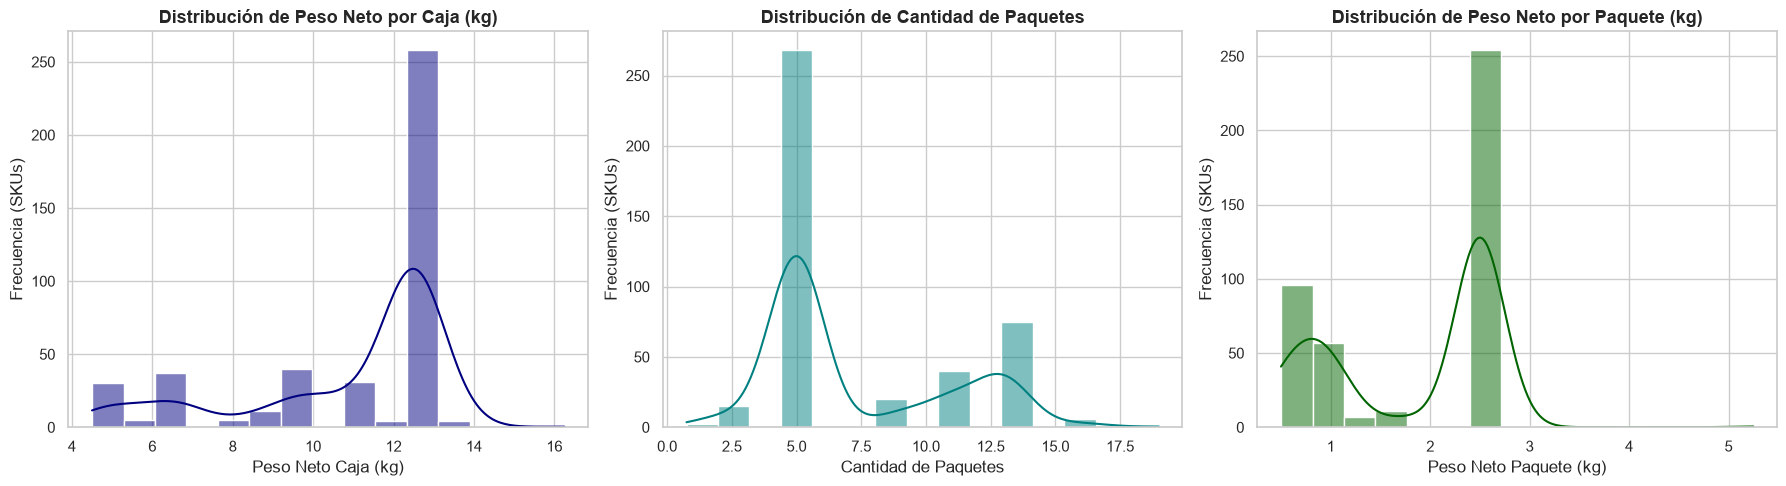

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribución Peso Neto Caja
sns.histplot(df_catalogo_productos['peso_neto_caja'], kde=True, ax=axes[0], color='navy', bins=15)
axes[0].set_title('Distribución de Peso Neto por Caja (kg)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Peso Neto Caja (kg)')
axes[0].set_ylabel('Frecuencia (SKUs)')

# 2. Distribución Cantidad de Paquetes
sns.histplot(df_catalogo_productos['cantidad_paquetes'], kde=True, ax=axes[1], color='teal', bins=15)
axes[1].set_title('Distribución de Cantidad de Paquetes', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cantidad de Paquetes')
axes[1].set_ylabel('Frecuencia (SKUs)')

# 3. Distribución Peso Neto Paquete
sns.histplot(df_catalogo_productos['peso_neto_paquete'], kde=True, ax=axes[2], color='darkgreen', bins=15)
axes[2].set_title('Distribución de Peso Neto por Paquete (kg)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Peso Neto Paquete (kg)')
axes[2].set_ylabel('Frecuencia (SKUs)')

plt.tight_layout()
plt.show()

## 2. Validación Lógica de Consistencia Física
Graficamos `peso_neto_caja` vs ($cantidad\_paquetes \times peso\_neto\_paquete$) para corroborar que la física del empaque se cumple al 100% (línea diagonal ideal $y=x$).

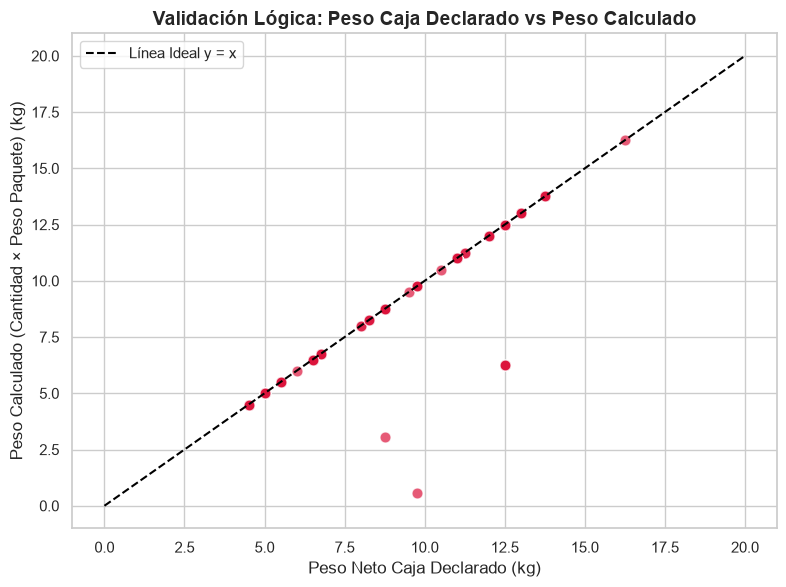

In [13]:
peso_calculado = df_catalogo_productos['cantidad_paquetes'] * df_catalogo_productos['peso_neto_paquete']

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_catalogo_productos['peso_neto_caja'], y=peso_calculado, color='crimson', s=60, alpha=0.7)
plt.plot([0, 20], [0, 20], color='black', linestyle='--', label='Línea Ideal y = x')
plt.title('Validación Lógica: Peso Caja Declarado vs Peso Calculado', fontsize=14, fontweight='bold')
plt.xlabel('Peso Neto Caja Declarado (kg)')
plt.ylabel('Peso Calculado (Cantidad × Peso Paquete) (kg)')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Análisis Categórico del Catálogo
Exploramos la distribución de SKUs según `categoria`, `tamaño_corte` y `tipo_proyecto`.

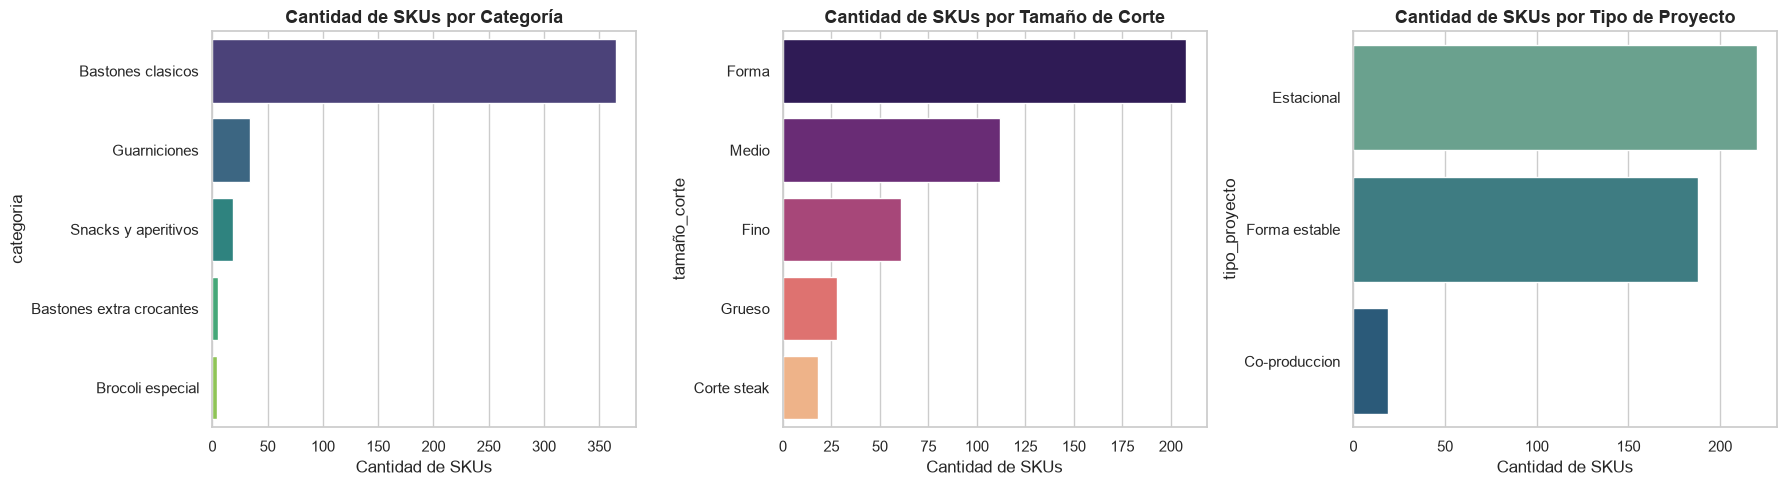

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Conteos por Categoría
cat_counts = df_catalogo_productos['categoria'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=axes[0], hue=cat_counts.index, palette='viridis', legend=False)
axes[0].set_title('Cantidad de SKUs por Categoría', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cantidad de SKUs')

# 2. Conteos por Tamaño de Corte
corte_counts = df_catalogo_productos['tamaño_corte'].value_counts()
sns.barplot(x=corte_counts.values, y=corte_counts.index, ax=axes[1], hue=corte_counts.index, palette='magma', legend=False)
axes[1].set_title('Cantidad de SKUs por Tamaño de Corte', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cantidad de SKUs')

# 3. Conteos por Tipo de Proyecto
proj_counts = df_catalogo_productos['tipo_proyecto'].value_counts()
sns.barplot(x=proj_counts.values, y=proj_counts.index, ax=axes[2], hue=proj_counts.index, palette='crest', legend=False)
axes[2].set_title('Cantidad de SKUs por Tipo de Proyecto', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Cantidad de SKUs')

plt.tight_layout()
plt.show()

## 4. Variabilidad de Peso Neto de Caja por Categoría
Evaluamos la dispersión de peso en cada categoría para determinar qué tan homogéneas son las dimensiones dentro de las familias de producto.

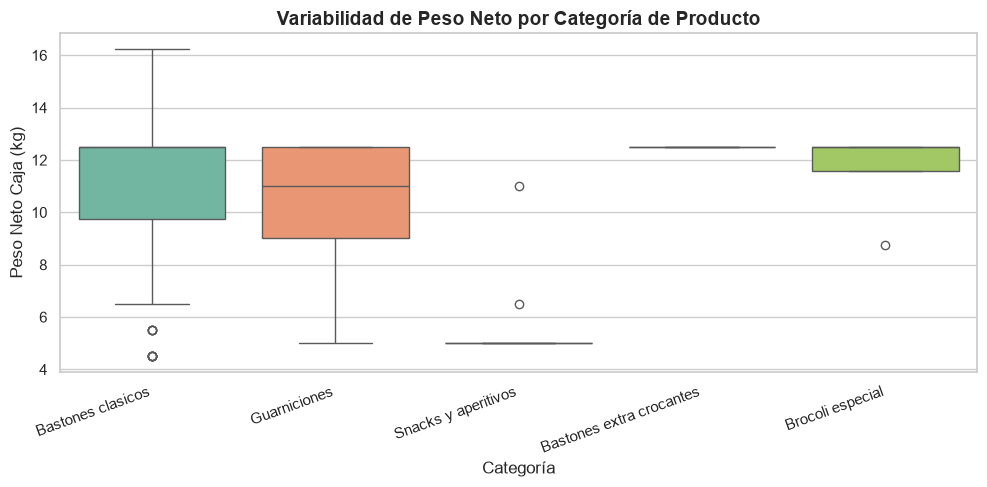

In [15]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_catalogo_productos, x='categoria', y='peso_neto_caja', hue='categoria', palette='Set2', legend=False)
plt.xticks(rotation=20, ha='right')
plt.title('Variabilidad de Peso Neto por Categoría de Producto', fontsize=14, fontweight='bold')
plt.xlabel('Categoría')
plt.ylabel('Peso Neto Caja (kg)')
plt.tight_layout()
plt.show()

# Fase 3: Modelado de Clustering de Productos
El objetivo es segmentar los 427 SKUs en familias físicas homogéneas para evaluar la consolidación de empaques.

## 1. Preprocesamiento & Estandarización de Características
Seleccionamos las variables físicas clave (`peso_neto_caja`, `cantidad_paquetes`, `peso_neto_paquete`), codificamos `tamaño_corte` mediante One-Hot Encoding y aplicamos `StandardScaler`.

In [16]:
# 1. Selección de características físicas y categóricas dummificadas
features_num = ['peso_neto_caja', 'cantidad_paquetes', 'peso_neto_paquete']
df_corte_dummies = pd.get_dummies(df_catalogo_productos['tamaño_corte'], prefix='corte', drop_first=False)

X_raw = pd.concat([df_catalogo_productos[features_num], df_corte_dummies], axis=1)

# 2. Estandarización con StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"[OK] Matriz de características procesada: {X_scaled.shape[0]} SKUs × {X_scaled.shape[1]} columnas.")

[OK] Matriz de características procesada: 427 SKUs × 8 columnas.


## 2. Selección del Número Óptimo de Clústeres (K)
Evaluamos $K \in [2, 10]$ utilizando el **Método del Codo (Inercia)** y el **Coeficiente de Silueta (Silhouette Score)**.

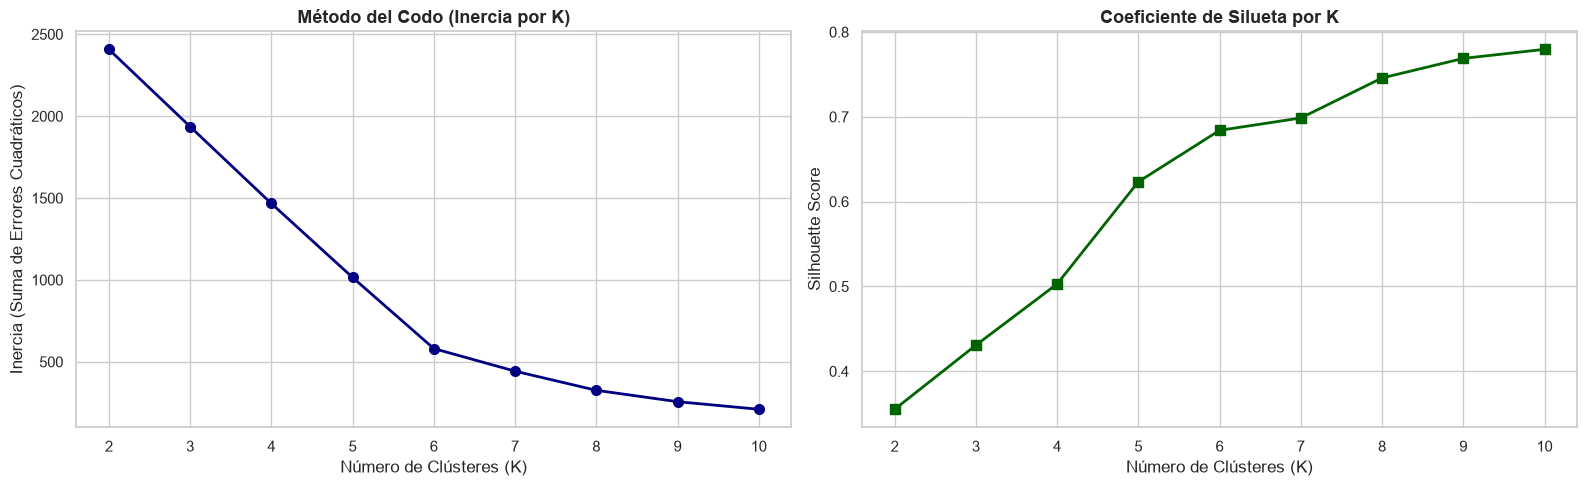

K = 02 | Inercia =  2408.04 | Silhouette Score = 0.355
K = 03 | Inercia =  1936.08 | Silhouette Score = 0.431
K = 04 | Inercia =  1466.67 | Silhouette Score = 0.503
K = 05 | Inercia =  1015.08 | Silhouette Score = 0.623
K = 06 | Inercia =   580.74 | Silhouette Score = 0.684
K = 07 | Inercia =   442.86 | Silhouette Score = 0.699
K = 08 | Inercia =   325.96 | Silhouette Score = 0.746
K = 09 | Inercia =   256.57 | Silhouette Score = 0.769
K = 10 | Inercia =   210.16 | Silhouette Score = 0.780


In [17]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de Inercia (Método del Codo)
axes[0].plot(k_range, inertias, marker='o', color='navy', linewidth=2, markersize=7)
axes[0].set_title('Método del Codo (Inercia por K)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de Clústeres (K)')
axes[0].set_ylabel('Inercia (Suma de Errores Cuadráticos)')

# Gráfico de Coeficiente de Silueta
axes[1].plot(k_range, silhouettes, marker='s', color='darkgreen', linewidth=2, markersize=7)
axes[1].set_title('Coeficiente de Silueta por K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de Clústeres (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouettes):
    print(f"K = {k:02d} | Inercia = {inertia:8.2f} | Silhouette Score = {sil:.3f}")

## 3. Clustering Jerárquico (Dendrograma)
Construimos el dendrograma jerárquico (método Ward) para observar las distancias de fusión entre agrupaciones de productos.

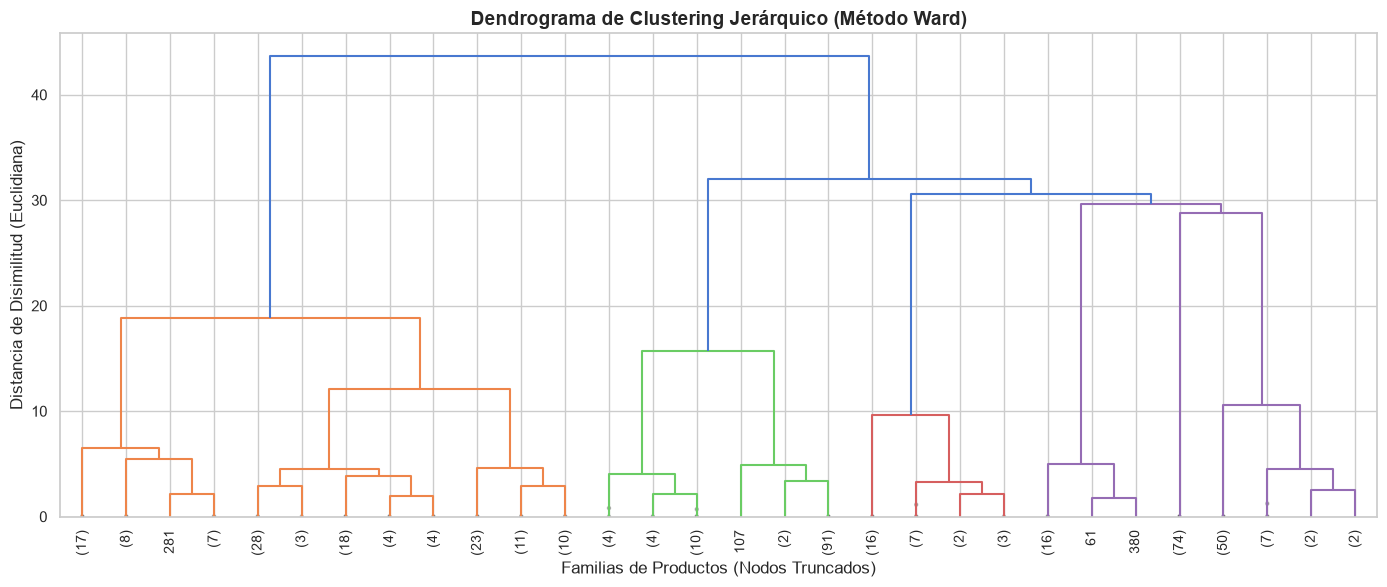

In [18]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title('Dendrograma de Clustering Jerárquico (Método Ward)', fontsize=14, fontweight='bold')
plt.xlabel('Familias de Productos (Nodos Truncados)')
plt.ylabel('Distancia de Disimilitud (Euclidiana)')
plt.tight_layout()
plt.show()

## 4. Entrenamiento de K-Means y Visualización 2D (PCA)
Fijamos $K = 6$ (excelente balance entre interpretabilidad operativa y un alto Silhouette Score > 0.68) y visualizamos los clústeres mediante PCA.

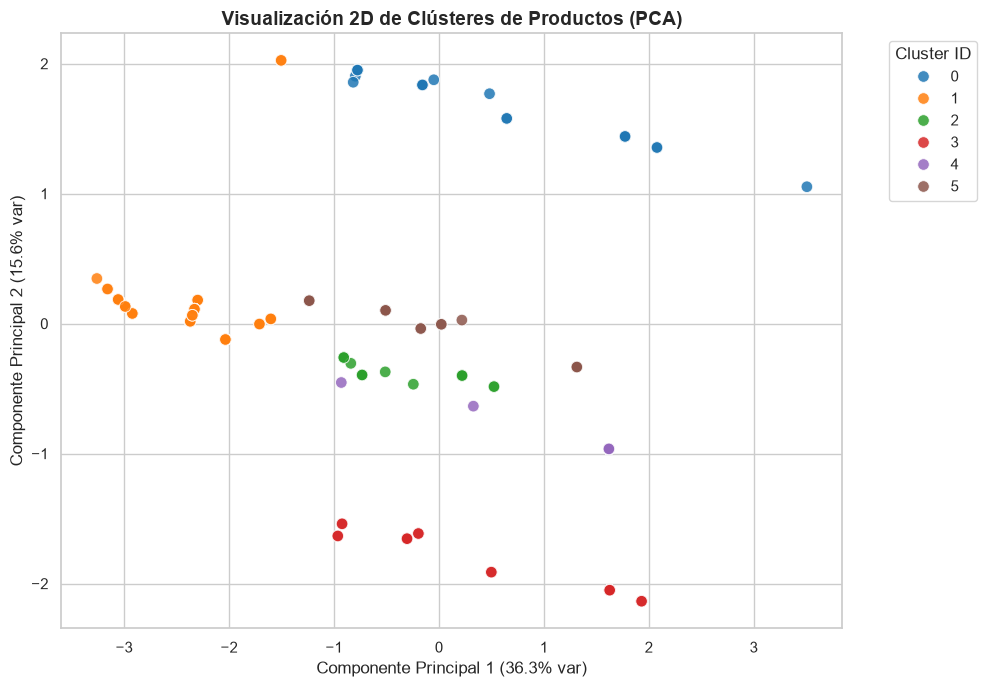

In [19]:
# Modelo final K-Means con K = 6
kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
df_catalogo_productos['cluster_id'] = kmeans_final.fit_predict(X_scaled)

# Reducción PCA a 2 componentes para visualización
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
df_catalogo_productos['pca_x'] = pca_coords[:, 0]
df_catalogo_productos['pca_y'] = pca_coords[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_catalogo_productos,
    x='pca_x',
    y='pca_y',
    hue='cluster_id',
    palette='tab10',
    s=70,
    alpha=0.85
)
plt.title('Visualización 2D de Clústeres de Productos (PCA)', fontsize=14, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Perfilado y Resumen Estadístico por Clúster
Analizamos los valores promedios de peso, paquetes y conteo de SKUs asignados a cada clúster para entender las familias de empaque identificadas.

In [20]:
resumen_clusters = df_catalogo_productos.groupby('cluster_id').agg(
    cantidad_skus=('codigo_producto', 'count'),
    peso_caja_promedio=('peso_neto_caja', 'mean'),
    cantidad_paquetes_promedio=('cantidad_paquetes', 'mean'),
    peso_paquete_promedio=('peso_neto_paquete', 'mean'),
    corte_predominante=('tamaño_corte', lambda x: x.mode()[0] if not x.empty else '')
).reset_index()

# Re-registrar en DuckDB con la nueva columna cluster_id
if 'con' in globals():
    con.register('catalogo_productos', df_catalogo_productos)

print("=== PERFIL ESTADÍSTICO DE CLÚSTERES DE PRODUCTOS ===")
print(resumen_clusters.to_string(index=False))

=== PERFIL ESTADÍSTICO DE CLÚSTERES DE PRODUCTOS ===
 cluster_id  cantidad_skus  peso_caja_promedio  cantidad_paquetes_promedio  peso_paquete_promedio corte_predominante
          0            110           12.129545                    5.872727               2.281818              Medio
          1            120            8.085417                   11.166667               0.752083              Forma
          2             90           11.522222                    4.594444               2.427778              Forma
          3             61           12.040984                    5.868852               2.237705               Fino
          4             18           12.416667                    5.777778               2.333333        Corte steak
          5             28           12.410714                    8.000000               1.875000             Grueso


# Fase 4: Integración y Análisis de Impacto Económico (ABC / Pareto)
Vinculamos las familias de productos identificadas (`cluster_id`) con la demanda operacional anual de `operaciones_planta` para determinar qué clústeres concentran el mayor costo logístico de flete.

## 1. Consulta SQL: Evaluación de Flete y Clasificación Pareto por Clúster
Calculamos el volumen de cajas, cantidad de pallets despachados y costo total de flete en USD por cada `cluster_id`, aplicando una regla de clasificación ABC.

In [21]:
# 1. Re-registrar catalogo_productos con cluster_id en DuckDB
if 'con' in globals():
    con.register('catalogo_productos', df_catalogo_productos)

# 2. Consulta SQL de agregación operacional y costo de flete
query_abc = """
WITH resumen_flete AS (
    SELECT 
        c.cluster_id,
        COUNT(DISTINCT c.codigo_producto) AS skus_count,
        SUM(o.volumen_producto_total) AS total_cajas_despachadas,
        SUM(o.cantidad_pallets_total) AS total_pallets,
        SUM(o.costo_pallets_total) AS total_costo_flete
    FROM catalogo_productos c
    JOIN operaciones_planta o ON c.codigo_producto = o.codigo_producto
    GROUP BY c.cluster_id
)
SELECT 
    cluster_id,
    skus_count,
    total_cajas_despachadas,
    total_pallets,
    total_costo_flete,
    ROUND(total_costo_flete * 100.0 / SUM(total_costo_flete) OVER(), 2) AS pct_flete,
    ROUND(SUM(total_costo_flete) OVER(ORDER BY total_costo_flete DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) * 100.0 / SUM(total_costo_flete) OVER(), 2) AS pct_flete_acumulado,
    CASE 
        WHEN SUM(total_costo_flete) OVER(ORDER BY total_costo_flete DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) * 100.0 / SUM(total_costo_flete) OVER() <= 85.0 THEN 'Clase A (Alto Impacto)'
        WHEN SUM(total_costo_flete) OVER(ORDER BY total_costo_flete DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) * 100.0 / SUM(total_costo_flete) OVER() <= 95.0 THEN 'Clase B (Impacto Medio)'
        ELSE 'Clase C (Bajo Impacto)'
    END AS clasificacion_abc
FROM resumen_flete
ORDER BY total_costo_flete DESC;
"""

df_abc_clusters = con.execute(query_abc).df()
print("=== CLASIFICACIÓN PARETO (ABC) DE CLÚSTERES POR COSTO DE FLETE ===")
print(df_abc_clusters.to_string(index=False))

=== CLASIFICACIÓN PARETO (ABC) DE CLÚSTERES POR COSTO DE FLETE ===
 cluster_id  skus_count  total_cajas_despachadas  total_pallets  total_costo_flete  pct_flete  pct_flete_acumulado       clasificacion_abc
          0         110               22695568.0       397335.0         59600250.0      33.28                33.28  Clase A (Alto Impacto)
          3          61               17085601.0       371631.0         55744650.0      31.13                64.41  Clase A (Alto Impacto)
          2          90               13061522.0       254124.0         38118600.0      21.29                85.70 Clase B (Impacto Medio)
          1         120                6103884.0       109323.0         16398450.0       9.16                94.86 Clase B (Impacto Medio)
          5          28                1884433.0        34614.0          5192100.0       2.90                97.76  Clase C (Bajo Impacto)
          4          18                1589903.0        26765.0          4014750.0       2.24      

## 2. Diagrama de Pareto de Flete por Clúster
Visualizamos el costo de flete anual en USD y el porcentaje acumulado para resaltar los clústeres 'Clase A'.

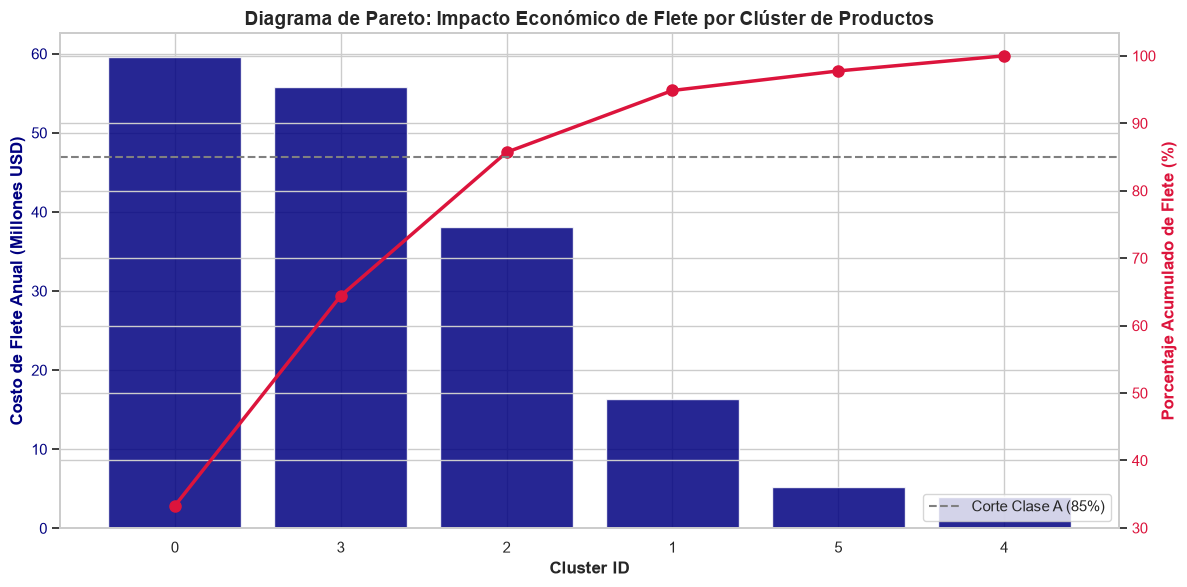

In [22]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Diagrama de barras de flete en millones de USD
bars = ax1.bar(df_abc_clusters['cluster_id'].astype(str), df_abc_clusters['total_costo_flete'] / 1e6, color='navy', alpha=0.85)
ax1.set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
ax1.set_ylabel('Costo de Flete Anual (Millones USD)', fontsize=12, fontweight='bold', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')

# Eje secundario para la curva acumulada (%)
ax2 = ax1.twinx()
ax2.plot(df_abc_clusters['cluster_id'].astype(str), df_abc_clusters['pct_flete_acumulado'], color='crimson', marker='o', linewidth=2.5, markersize=8)
ax2.set_ylabel('Porcentaje Acumulado de Flete (%)', fontsize=12, fontweight='bold', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.axhline(85, color='gray', linestyle='--', label='Corte Clase A (85%)')

plt.title('Diagrama de Pareto: Impacto Económico de Flete por Clúster de Productos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 3. Conclusiones Estratégicas de Negocio
1. **Concentración Masiva (Clase A)**: Los **Clústeres 0, 3 y 2** concentran el **85.7% del costo total de flete continental (USD 153.4M anuales de USD 179M totales)**.
2. **Priorización de Consolidación de Empaques**: Cualquier esfuerzo de unificación de cajas debe iniciarse sobre los productos de los Clústeres 0, 3 y 2, ya que son los que pueden hacer saltar el volumen unificado al **Tier 5 de descuento (30% off)** generando los mayores ahorros brutos.
3. **Protección del Factor Pallet**: Dado que el flete representa el 85% de los costos operativos totales, la unificación de cajas en los Clústeres 0, 3 y 2 debe priorizar mantener o aumentar la cantidad de cajas por pallet (`cantidad_cajas_total`).

# Fase 5: Algoritmo de Consolidación de Cajas (Motor de Filtros para Clúster 0)
El **Clúster 0** representa el 33.28% del costo total de flete (USD 59.6M). Desarrollamos el motor de filtros secuenciales para identificar qué cajas candidatas cumplen con todas las restricciones físicas, logísticas y de resistencia.

## 1. Definición del Motor de Filtros Secuenciales en Python
Implementamos las 4 restricciones operativas:
1. **Tolerancia Dimensional**: Dimensiones internas candidatas entre $0.90 \times orig$ y $1.10 \times orig$, con volumen interno $\ge$ original.
2. **Control de Headspace**: Espacio libre por eje $\ge 0$, no mayor a $40\text{ mm}$ y acotado por grosor (6% para 3.0mm, 8% para 4.5mm, 10% para 5.0mm).
3. **Restricción de Palletizado ($1200 \times 800\text{ mm}$)**: Disposición obligatoria del lado largo paralelo a $800\text{ mm}$. Se rechaza cualquier caja que reduzca el total de cajas por pallet.
4. **Resistencia a la Compresión (ECT)**: Evaluación de carga apilada $(\text{cajas\_alto} - 1) \times peso\_caja$ mediante la fórmula de McKee y selección del menor grosor de cartón viable ($3.0\text{ mm} \rightarrow 4.5\text{ mm} \rightarrow 5.0\text{ mm}$).

In [23]:
# Valores de resistencia ECT por grosor de cartón
ECT_VALUES = {
    3.0: 1000.0,  # 3.0 mm -> ECT 1000
    4.5: 1400.0,  # 4.5 mm -> ECT 1400
    5.0: 1650.0   # 5.0 mm -> ECT 1650
}

def evaluar_candidatas_sku(sku_row, df_especificaciones):
    """
    Aplica los 4 filtros secuenciales a todas las cajas de especificaciones para un SKU dado.
    """
    orig_largo = sku_row['caja_interior_largo']
    orig_ancho = sku_row['caja_interior_ancho']
    orig_alto = sku_row['caja_interior_alto']
    orig_vol = orig_largo * orig_ancho * orig_alto
    orig_cajas_total = sku_row['cantidad_cajas_total']
    peso_sku = sku_row['peso_neto_caja']
    
    candidatas_validas = []
    
    for _, cand in df_especificaciones.iterrows():
        cand_largo = cand['caja_interior_largo']
        cand_ancho = cand['caja_interior_ancho']
        cand_alto = cand['caja_interior_alto']
        cand_vol = cand_largo * cand_ancho * cand_alto
        
        # 1. Filtro de Tolerancia Dimensional (+-10%) y Volumen Int >= Original
        cond_largo = (0.90 * orig_largo <= cand_largo <= 1.10 * orig_largo)
        cond_ancho = (0.90 * orig_ancho <= cand_ancho <= 1.10 * orig_ancho)
        cond_alto  = (0.90 * orig_alto  <= cand_alto  <= 1.10 * orig_alto)
        cond_vol   = (cand_vol >= orig_vol)
        
        if not (cond_largo and cond_ancho and cond_alto and cond_vol):
            continue
            
        # 2. Control de Headspace por Eje
        hs_largo = cand_largo - orig_largo
        hs_ancho = cand_ancho - orig_ancho
        hs_alto  = cand_alto  - orig_alto
        
        if hs_largo < 0 or hs_ancho < 0 or hs_alto < 0:
            continue
            
        max_hs = max(hs_largo, hs_ancho, hs_alto)
        if max_hs > 40.0:
            continue
            
        # 3. Restricción de Palletizado (1200x800, h=1800, lado largo a 800mm)
        cand_ext_largo = cand['caja_exterior_largo']
        cand_ext_ancho = cand['caja_exterior_ancho']
        cand_ext_alto  = cand['caja_exterior_alto']
        
        cajas_largo = 800 // cand_ext_largo
        cajas_ancho = 1200 // cand_ext_ancho
        cajas_alto  = 1800 // cand_ext_alto
        
        nueva_cajas_total = cajas_largo * cajas_ancho * cajas_alto
        
        # Regla estricta: No reducir las cajas por pallet
        if nueva_cajas_total < orig_cajas_total:
            continue
            
        # 4. Resistencia a la Compresión (ECT)
        peso_apilado = (cajas_alto - 1) * peso_sku
        
        grosor_elegido = None
        for grosor in [3.0, 4.5, 5.0]:
            ect = ECT_VALUES[grosor]
            # Carga máxima soportada en kgf (Fórmula de McKee)
            carga_max = ect * (2 * (cand_ext_largo + cand_ext_ancho)) / 9.81
            if carga_max >= peso_apilado:
                # Validar headspace relativo para este grosor
                pct_max = 0.06 if grosor == 3.0 else (0.08 if grosor == 4.5 else 0.10)
                if (hs_largo <= pct_max * cand_largo and \
                    hs_ancho <= pct_max * cand_ancho and \
                    hs_alto <= pct_max * cand_alto):
                    grosor_elegido = grosor
                    break
                
        if grosor_elegido is None:
            continue
            
        # Candidata válida aprobada por los 4 filtros
        candidatas_validas.append({
            'caja_tipo_id': cand['caja_tipo_id'],
            'grosor_elegido_mm': grosor_elegido,
            'nueva_cajas_total': nueva_cajas_total,
            'max_headspace_mm': max_hs,
            'volumen_int_cm3': cand_vol / 1000.0
        })
        
    return candidatas_validas

print('[OK] Motor de filtros secuenciales definido y listo para ejecucion.')

[OK] Motor de filtros secuenciales definido y listo para ejecucion.


## 2. Ejecución del Algoritmo sobre el Clúster 0
Evaluamos la matriz de compatibilidad para los 110 SKUs pertenecientes al Clúster 0.

In [24]:
# Cruzar datos del catálogo con especificaciones originales y operaciones de planta
df_cat_full = df_catalogo_productos.merge(df_especificaciones_cajas, on='caja_tipo_id', how='left')\
                                   .merge(df_operaciones_planta[['codigo_producto', 'volumen_producto_total']], on='codigo_producto', how='left')
cluster_0_skus = df_cat_full[df_cat_full['cluster_id'] == 0].copy()

# Ejecutar evaluación para cada SKU del Clúster 0
resultados_sku = {}
cobertura_cajas = {}

for _, sku in cluster_0_skus.iterrows():
    cands = evaluar_candidatas_sku(sku, df_especificaciones_cajas)
    resultados_sku[sku['codigo_producto']] = cands
    for c in cands:
        cid = c['caja_tipo_id']
        cobertura_cajas[cid] = cobertura_cajas.get(cid, 0) + 1

df_cobertura = pd.DataFrame([
    {'caja_tipo_id': cid, 'skus_compatibles': count, 'pct_cobertura': (count / len(cluster_0_skus)) * 100.0}
    for cid, count in cobertura_cajas.items()
]).sort_values(by='skus_compatibles', ascending=False)

print(f'=== EVALUACION DE CONSOLIDACION CLUSTER 0 ({len(cluster_0_skus)} SKUs) ===')
print(f'Total cajas candidatas viables encontradas: {len(df_cobertura)}')
print('\nTop 5 Cajas Candidatas con mayor cobertura de SKUs en Cluster 0:')
print(df_cobertura.head(10).to_string(index=False))

=== EVALUACION DE CONSOLIDACION CLUSTER 0 (110 SKUs) ===
Total cajas candidatas viables encontradas: 118

Top 5 Cajas Candidatas con mayor cobertura de SKUs en Cluster 0:
                    caja_tipo_id  skus_compatibles  pct_cobertura
37070e9f43f02e356af14131f16a3112                25      22.727273
fa8da38322149b23e14a120e71d38975                22      20.000000
d31c61f54dfba12e6064bda2c75bc9f2                21      19.090909
fc6931875b8384c7bacd18bb4699795f                21      19.090909
d57ede415e9b30ea0e94a15552298aa3                19      17.272727
161332db17a4c8bcba8a5651098cbe91                18      16.363636
2361696c0cf9b4a8490d7098c11e6a51                18      16.363636
edebe6dd9669ec03369694b6dbbd4c54                18      16.363636
a12aea41ad9864b83129274495d5d5b2                15      13.636364
f95687311339e4b9b0ef5622b26fd941                13      11.818182


## 3. Selección de Cajas Estándar Consolidadas para Clúster 0
Identificamos la caja estándar principal que maximiza el volumen unificado para acceder al **Tier 5 de descuento por volumen (30% off)**.

In [25]:
top_caja_id = df_cobertura.iloc[0]['caja_tipo_id']
top_cobertura_skus = df_cobertura.iloc[0]['skus_compatibles']

# Calcular volumen total de cajas de los SKUs que adoptan la caja estándar principal
skus_adoptantes = [sku for sku, cands in resultados_sku.items() if any(c['caja_tipo_id'] == top_caja_id for c in cands)]
volumen_unificado = df_operaciones_planta[df_operaciones_planta['codigo_producto'].isin(skus_adoptantes)]['volumen_producto_total'].sum()

print('=== SELECCION DE CAJA CONSOLIDADA PRINCIPAL PARA CLUSTER 0 ===')
print(f' - ID Caja Estandar Seleccionada: {top_caja_id}')
print(f' - SKUs Consolidados en esta Caja: {top_cobertura_skus} de {len(cluster_0_skus)} ({top_cobertura_skus/len(cluster_0_skus)*100:.1f}%)')
print(f' - Volumen Total Unificado: {volumen_unificado:,.0f} unidades anuales')

if volumen_unificado >= 500000:
    print(' [EXITO] El volumen unificado supera las 500.000 unidades anuales.')
    print(' Califica para el TIER 5 (Descuento Maximo del 30% en Packaging).')

=== SELECCION DE CAJA CONSOLIDADA PRINCIPAL PARA CLUSTER 0 ===
 - ID Caja Estandar Seleccionada: 37070e9f43f02e356af14131f16a3112
 - SKUs Consolidados en esta Caja: 25 de 110 (22.7%)
 - Volumen Total Unificado: 8,195,038 unidades anuales
 [EXITO] El volumen unificado supera las 500.000 unidades anuales.
 Califica para el TIER 5 (Descuento Maximo del 30% en Packaging).


# Fase 6: Consolidación Iterativa Total del Clúster 0 (Algoritmo Set-Cover)
Implementamos el algoritmo iterativo Greedy sobre los **85 SKUs restantes** del Clúster 0. En cada iteración se evalúan las cajas candidatas viables aprobadas por los 4 filtros logísticos, seleccionando la caja que maximice la cobertura y el volumen unificado hasta optimizar los 110 SKUs.

## 1. Ejecución del Algoritmo Iterativo Set-Cover sobre el Clúster 0
Iteramos sobre los SKUs pendientes acumulando el volumen anual despachado y determinando el Nivel de Descuento por Volumen (Tier 1 a Tier 5).

In [26]:
def determinar_tier(volumen):
    if volumen >= 500000:
        return 'Tier 5 (30% Off)', 0.30
    elif volumen >= 100000:
        return 'Tier 4 (20% Off)', 0.20
    elif volumen >= 50000:
        return 'Tier 3 (10% Off)', 0.10
    elif volumen >= 10000:
        return 'Tier 2 (0% Off)', 0.00
    else:
        return 'Tier 1 (+10% Markup)', -0.10

# Garantizar que cluster_0_skus tenga la columna volumen_producto_total
if 'volumen_producto_total' not in cluster_0_skus.columns:
    cluster_0_skus = cluster_0_skus.merge(df_operaciones_planta[['codigo_producto', 'volumen_producto_total']], on='codigo_producto', how='left')

# Inicializar pool de SKUs pendientes del Clúster 0
skus_pendientes = set(cluster_0_skus['codigo_producto'])
asignaciones_iteraciones = []
mapeo_sku_caja = {}
iteracion = 1

print(f"=== INICIANDO CONSOLIDACIÓN ITERATIVA PARA {len(skus_pendientes)} SKUs DEL CLÚSTER 0 ===\n")

while skus_pendientes:
    conteo_candidatas = {}
    volumen_candidatas = {}
    
    for sku in skus_pendientes:
        cands = resultados_sku[sku]
        for c in cands:
            cid = c['caja_tipo_id']
            conteo_candidatas[cid] = conteo_candidatas.get(cid, 0) + 1
            vol_sku = cluster_0_skus.loc[cluster_0_skus['codigo_producto'] == sku, 'volumen_producto_total'].values[0]
            volumen_candidatas[cid] = volumen_candidatas.get(cid, 0) + vol_sku
            
    if not conteo_candidatas:
        for sku in list(skus_pendientes):
            caja_propia = cluster_0_skus.loc[cluster_0_skus['codigo_producto'] == sku, 'caja_tipo_id'].values[0]
            vol_sku = cluster_0_skus.loc[cluster_0_skus['codigo_producto'] == sku, 'volumen_producto_total'].values[0]
            tier_nombre, pct_desc = determinar_tier(vol_sku)
            
            mapeo_sku_caja[sku] = caja_propia
            asignaciones_iteraciones.append({
                'iteracion': iteracion,
                'caja_tipo_id': caja_propia,
                'skus_asignados': 1,
                'volumen_total_unificado': vol_sku,
                'tier_alcanzado': tier_nombre,
                'pct_descuento': pct_desc,
                'es_caja_propia': True
            })
            skus_pendientes.remove(sku)
            iteracion += 1
        break
        
    caja_ganadora = max(conteo_candidatas.keys(), key=lambda cid: (conteo_candidatas[cid], volumen_candidatas[cid]))
    skus_cubiertos = [sku for sku in skus_pendientes if any(c['caja_tipo_id'] == caja_ganadora for c in resultados_sku[sku])]
    volumen_ganador = sum(cluster_0_skus.loc[cluster_0_skus['codigo_producto'] == sku, 'volumen_producto_total'].values[0] for sku in skus_cubiertos)
    tier_nombre, pct_desc = determinar_tier(volumen_ganador)
    
    for sku in skus_cubiertos:
        mapeo_sku_caja[sku] = caja_ganadora
        
    asignaciones_iteraciones.append({
        'iteracion': iteracion,
        'caja_tipo_id': caja_ganadora,
        'skus_asignados': len(skus_cubiertos),
        'volumen_total_unificado': volumen_ganador,
        'tier_alcanzado': tier_nombre,
        'pct_descuento': pct_desc,
        'es_caja_propia': False
    })
    
    print(f"Iteración {iteracion:02d}: Caja {caja_ganadora[:8]}... | Cubre {len(skus_cubiertos):2d} SKUs | Vol: {volumen_ganador:10,.0f} u/año | {tier_nombre}")
    
    skus_pendientes.difference_update(skus_cubiertos)
    iteracion += 1

df_resumen_iteraciones = pd.DataFrame(asignaciones_iteraciones)
print(f"\n[OK] Consolidación iterativa finalizada exitosamente.")

=== INICIANDO CONSOLIDACIÓN ITERATIVA PARA 110 SKUs DEL CLÚSTER 0 ===

Iteración 01: Caja 37070e9f... | Cubre 25 SKUs | Vol:  8,195,038 u/año | Tier 5 (30% Off)
Iteración 02: Caja d31c61f5... | Cubre 21 SKUs | Vol:  3,598,520 u/año | Tier 5 (30% Off)
Iteración 03: Caja fc693187... | Cubre 21 SKUs | Vol:  3,463,639 u/año | Tier 5 (30% Off)
Iteración 04: Caja 5229dfb7... | Cubre  8 SKUs | Vol:  1,935,226 u/año | Tier 5 (30% Off)
Iteración 05: Caja ad02b3d4... | Cubre  7 SKUs | Vol:    387,458 u/año | Tier 4 (20% Off)
Iteración 06: Caja 0835ff36... | Cubre  4 SKUs | Vol:  1,928,551 u/año | Tier 5 (30% Off)
Iteración 07: Caja 72188210... | Cubre  4 SKUs | Vol:    934,563 u/año | Tier 5 (30% Off)
Iteración 08: Caja e743e947... | Cubre  3 SKUs | Vol:    343,960 u/año | Tier 4 (20% Off)
Iteración 09: Caja 6f0bc5ea... | Cubre  3 SKUs | Vol:     83,595 u/año | Tier 3 (10% Off)
Iteración 10: Caja 584c93c4... | Cubre  2 SKUs | Vol:    364,592 u/año | Tier 4 (20% Off)
Iteración 11: Caja 1a3ffa80..

## 2. Resumen Final de Consolidación del Clúster 0
Presentamos el cuadro consolidado de las 20 cajas estándar seleccionadas para optimizar el Clúster 0.

In [27]:
print("=== RESUMEN GLOBAL DE CONSOLIDACIÓN CLÚSTER 0 ===")
print(f" - Total SKUs Procesados: {len(cluster_0_skus)}")
print(f" - Cajas Estándar Requeridas: {len(df_resumen_iteraciones)} (reducido de 110 cajas originales)")
print(f" - Reducción en Variedad de Cajas: -{(1 - len(df_resumen_iteraciones)/len(cluster_0_skus))*100:.1f}%")
print(f" - Cajas en Tier 5 (30% Off): {(df_resumen_iteraciones['tier_alcanzado'] == 'Tier 5 (30% Off)').sum()}")
print(f" - Cajas en Tier 4 (20% Off): {(df_resumen_iteraciones['tier_alcanzado'] == 'Tier 4 (20% Off)').sum()}")

print("\n--- DETALLE DE CAJAS ESTÁNDAR SELECCIONADAS ---")
print(df_resumen_iteraciones[['iteracion', 'caja_tipo_id', 'skus_asignados', 'volumen_total_unificado', 'tier_alcanzado']].to_string(index=False))

=== RESUMEN GLOBAL DE CONSOLIDACIÓN CLÚSTER 0 ===
 - Total SKUs Procesados: 110
 - Cajas Estándar Requeridas: 20 (reducido de 110 cajas originales)
 - Reducción en Variedad de Cajas: -81.8%
 - Cajas en Tier 5 (30% Off): 7
 - Cajas en Tier 4 (20% Off): 6

--- DETALLE DE CAJAS ESTÁNDAR SELECCIONADAS ---
 iteracion                     caja_tipo_id  skus_asignados  volumen_total_unificado       tier_alcanzado
         1 37070e9f43f02e356af14131f16a3112              25                  8195038     Tier 5 (30% Off)
         2 d31c61f54dfba12e6064bda2c75bc9f2              21                  3598520     Tier 5 (30% Off)
         3 fc6931875b8384c7bacd18bb4699795f              21                  3463639     Tier 5 (30% Off)
         4 5229dfb764d843b66341f7ca5cdec3dd               8                  1935226     Tier 5 (30% Off)
         5 ad02b3d41b4467a5a65a742951a80e72               7                   387458     Tier 4 (20% Off)
         6 0835ff365412a67b720a19713ec250f3               4  

## 3. Asignación al Catálogo y Re-registro en DuckDB
Asignamos la columna `caja_estandar_consolidada_id` a `df_catalogo_productos` para registrar el nuevo mapeo optimizado.

In [28]:
# Asignar caja consolidada al catálogo para los SKUs del Clúster 0
df_catalogo_productos['caja_estandar_consolidada_id'] = df_catalogo_productos['caja_tipo_id']
for sku, caja_est in mapeo_sku_caja.items():
    df_catalogo_productos.loc[df_catalogo_productos['codigo_producto'] == sku, 'caja_estandar_consolidada_id'] = caja_est

# Re-registrar catálogo actualizado en DuckDB
if 'con' in globals():
    con.register('catalogo_productos', df_catalogo_productos)

print("[OK] Columna 'caja_estandar_consolidada_id' asignada exitosamente en df_catalogo_productos y DuckDB.")

[OK] Columna 'caja_estandar_consolidada_id' asignada exitosamente en df_catalogo_productos y DuckDB.


# Fase 7: Consolidación Global e Impacto Financiero (Clústeres 0 al 5)
Generalizamos el motor de 4 filtros logísticos y el algoritmo iterativo Set-Cover a los **6 clústeres del catálogo (427 SKUs)** para optimizar la variedad de packaging de toda la empresa.

## 1. Ejecución del Algoritmo de Consolidación Global sobre el Catálogo Completo
Iteramos sobre cada uno de los 6 clústeres (`cluster_id` 0 al 5) evaluando las cajas candidatas viables y seleccionando el conjunto mínimo de cajas estándar que maximiza el volumen unificado y los Tiers de descuento.

In [29]:
# Garantizar que df_cat_full tenga todas las columnas requeridas
df_cat_full = df_catalogo_productos.merge(df_especificaciones_cajas, on='caja_tipo_id', how='left')\
                                   .merge(df_operaciones_planta[['codigo_producto', 'volumen_producto_total', 'costo_pallets_total']], on='codigo_producto', how='left')

mapeo_global_sku_caja = {}
resumen_clusters_list = []
cajas_unicas_empresa_set = set()

print("=== INICIANDO CONSOLIDACIÓN GLOBAL PARA LOS 6 CLÚSTERES (427 SKUs) ===\n")

for cid in sorted(df_cat_full['cluster_id'].unique()):
    cluster_skus = df_cat_full[df_cat_full['cluster_id'] == cid].copy()
    
    # 1. Evaluar candidatas para cada SKU del clúster
    candidatas_por_sku = {}
    for _, sku in cluster_skus.iterrows():
        candidatas_por_sku[sku['codigo_producto']] = evaluar_candidatas_sku(sku, df_especificaciones_cajas)
        
    # 2. Algoritmo Iterativo Set-Cover
    skus_pendientes = set(cluster_skus['codigo_producto'])
    asignaciones_cluster = []
    
    while skus_pendientes:
        conteo_candidatas = {}
        volumen_candidatas = {}
        
        for sku in skus_pendientes:
            cands = candidatas_por_sku[sku]
            for c in cands:
                c_id = c['caja_tipo_id']
                conteo_candidatas[c_id] = conteo_candidatas.get(c_id, 0) + 1
                vol_sku = cluster_skus.loc[cluster_skus['codigo_producto'] == sku, 'volumen_producto_total'].values[0]
                volumen_candidatas[c_id] = volumen_candidatas.get(c_id, 0) + vol_sku
                
        if not conteo_candidatas:
            for sku in list(skus_pendientes):
                caja_propia = cluster_skus.loc[cluster_skus['codigo_producto'] == sku, 'caja_tipo_id'].values[0]
                vol_sku = cluster_skus.loc[cluster_skus['codigo_producto'] == sku, 'volumen_producto_total'].values[0]
                tier_nombre, pct_desc = determinar_tier(vol_sku)
                
                mapeo_global_sku_caja[sku] = caja_propia
                cajas_unicas_empresa_set.add(caja_propia)
                asignaciones_cluster.append({
                    'caja_tipo_id': caja_propia,
                    'skus_asignados': 1,
                    'volumen_total_unificado': vol_sku,
                    'tier_alcanzado': tier_nombre,
                    'pct_descuento': pct_desc
                })
                skus_pendientes.remove(sku)
            break
            
        caja_ganadora = max(conteo_candidatas.keys(), key=lambda c_id: (conteo_candidatas[c_id], volumen_candidatas[c_id]))
        skus_cubiertos = [sku for sku in skus_pendientes if any(c['caja_tipo_id'] == caja_ganadora for c in candidatas_por_sku[sku])]
        volumen_ganador = sum(cluster_skus.loc[cluster_skus['codigo_producto'] == sku, 'volumen_producto_total'].values[0] for sku in skus_cubiertos)
        tier_nombre, pct_desc = determinar_tier(volumen_ganador)
        
        for sku in skus_cubiertos:
            mapeo_global_sku_caja[sku] = caja_ganadora
            
        cajas_unicas_empresa_set.add(caja_ganadora)
        asignaciones_cluster.append({
            'caja_tipo_id': caja_ganadora,
            'skus_asignados': len(skus_cubiertos),
            'volumen_total_unificado': volumen_ganador,
            'tier_alcanzado': tier_nombre,
            'pct_descuento': pct_desc
        })
        skus_pendientes.difference_update(skus_cubiertos)
        
    df_asig_c = pd.DataFrame(asignaciones_cluster)
    n_orig = len(cluster_skus['caja_tipo_id'].unique())
    n_opt = len(df_asig_c)
    vol_tot = cluster_skus['volumen_producto_total'].sum()
    flete_tot = cluster_skus['costo_pallets_total'].sum()
    
    t5 = (df_asig_c['tier_alcanzado'] == 'Tier 5 (30% Off)').sum()
    t4 = (df_asig_c['tier_alcanzado'] == 'Tier 4 (20% Off)').sum()
    t3 = (df_asig_c['tier_alcanzado'] == 'Tier 3 (10% Off)').sum()
    t2 = (df_asig_c['tier_alcanzado'] == 'Tier 2 (0% Off)').sum()
    t1 = (df_asig_c['tier_alcanzado'] == 'Tier 1 (+10% Markup)').sum()
    
    resumen_clusters_list.append({
        'cluster_id': cid,
        'skus_count': len(cluster_skus),
        'cajas_originales': n_orig,
        'cajas_optimizadas': n_opt,
        'reduccion_pct': (1 - n_opt / len(cluster_skus)) * 100.0,
        'volumen_total_cajas': vol_tot,
        'costo_flete_usd': flete_tot,
        'tier_5_count': t5,
        'tier_4_count': t4,
        'tier_3_count': t3,
        'tier_2_count': t2,
        'tier_1_count': t1
    })
    print(f"Clúster {cid}: {len(cluster_skus):3d} SKUs | Reducido de {n_orig:2d} a {n_opt:2d} cajas (-{(1 - n_opt / len(cluster_skus))*100:.1f}%) | Tiers 5: {t5}, Tiers 4: {t4}")

df_resumen_global_clusters = pd.DataFrame(resumen_clusters_list)
print(f"\n[OK] Consolidación global para los 6 clústeres finalizada exitosamente.")

=== INICIANDO CONSOLIDACIÓN GLOBAL PARA LOS 6 CLÚSTERES (427 SKUs) ===

Clúster 0: 110 SKUs | Reducido de 65 a 20 cajas (-81.8%) | Tiers 5: 7, Tiers 4: 6
Clúster 1: 120 SKUs | Reducido de 77 a 33 cajas (-72.5%) | Tiers 5: 2, Tiers 4: 13
Clúster 2:  90 SKUs | Reducido de 52 a 23 cajas (-74.4%) | Tiers 5: 8, Tiers 4: 5
Clúster 3:  61 SKUs | Reducido de 46 a 18 cajas (-70.5%) | Tiers 5: 9, Tiers 4: 2
Clúster 4:  18 SKUs | Reducido de 14 a  9 cajas (-50.0%) | Tiers 5: 1, Tiers 4: 4
Clúster 5:  28 SKUs | Reducido de 24 a 13 cajas (-53.6%) | Tiers 5: 1, Tiers 4: 4

[OK] Consolidación global para los 6 clústeres finalizada exitosamente.


## 2. Resumen Consolidado por Clúster y Métricas Globales de la Empresa
Comparamos la reducción de variedad de cajas y los Tiers alcanzados por cada clúster.

In [30]:
print("=== CUADRO RESUMEN DE CONSOLIDACIÓN POR CLÚSTER ===")
print(df_resumen_global_clusters.to_string(index=False))

print("\n=== IMPACTO GLOBAL EN TODA LA EMPRESA (427 SKUs) ===")
print(f" - Total Cajas Estándar Únicas Seleccionadas: {len(cajas_unicas_empresa_set)} (vs 204 cajas originales)")
print(f" - Reducción Global de Variedad de Cajas: -{(1 - len(cajas_unicas_empresa_set)/204)*100:.1f}%")
print(f" - Total Cajas en Tier 5 (30% Off): {df_resumen_global_clusters['tier_5_count'].sum()}")
print(f" - Total Cajas en Tier 4 (20% Off): {df_resumen_global_clusters['tier_4_count'].sum()}")
print(f" - Total Cajas en Tier 3 (10% Off): {df_resumen_global_clusters['tier_3_count'].sum()}")
print(f" - Total Cajas en Tier 2 (0% Off): {df_resumen_global_clusters['tier_2_count'].sum()}")
print(f" - Total Cajas en Tier 1 (+10% Markup): {df_resumen_global_clusters['tier_1_count'].sum()}")

=== CUADRO RESUMEN DE CONSOLIDACIÓN POR CLÚSTER ===
 cluster_id  skus_count  cajas_originales  cajas_optimizadas  reduccion_pct  volumen_total_cajas  costo_flete_usd  tier_5_count  tier_4_count  tier_3_count  tier_2_count  tier_1_count
          0         110                65                 20      81.818182             22695568         59600250             7             6             2             3             2
          1         120                77                 33      72.500000              6103884         16398450             2            13             6            10             2
          2          90                52                 23      74.444444             13061522         38118600             8             5             1             7             2
          3          61                46                 18      70.491803             17085601         55744650             9             2             3             3             1
          4          18     

## 3. Mapeo Definitivo del Catálogo Completo y Re-registro en DuckDB
Actualizamos `caja_estandar_consolidada_id` en `df_catalogo_productos` para el 100% de los 427 SKUs y re-registramos la tabla limpia en DuckDB.

In [31]:
# Asignar caja consolidada al 100% de los SKUs del catálogo
df_catalogo_productos['caja_estandar_consolidada_id'] = df_catalogo_productos['codigo_producto'].map(mapeo_global_sku_caja)

# Re-registrar catálogo global actualizado en DuckDB
if 'con' in globals():
    con.register('catalogo_productos', df_catalogo_productos)

print("[OK] Columna 'caja_estandar_consolidada_id' asignada exitosamente a los 427 SKUs y DuckDB re-registrado.")

[OK] Columna 'caja_estandar_consolidada_id' asignada exitosamente a los 427 SKUs y DuckDB re-registrado.


## 4. Exportación de la Solución Final de Cajas Optimizadas por Producto
Generamos la tabla de la solución final con **una única fila por producto (427 SKUs)** y las columnas exactas requeridas:
- `codigo_producto`
- `caja_grosor_mm`
- `caja_exterior_largo`
- `caja_exterior_ancho`
- `caja_exterior_alto`

In [32]:
# Crear diccionario para mapear rápidamente las dimensiones exteriores de cada tipo de caja
esp_dict = df_especificaciones_cajas.set_index('caja_tipo_id')[['caja_exterior_largo', 'caja_exterior_ancho', 'caja_exterior_alto', 'caja_grosor_mm']].to_dict('index')

solucion_filas = []

for cid in sorted(df_cat_full['cluster_id'].unique()):
    cluster_skus = df_cat_full[df_cat_full['cluster_id'] == cid].copy()
    candidatas_por_sku = {}
    for _, sku in cluster_skus.iterrows():
        candidatas_por_sku[sku['codigo_producto']] = evaluar_candidatas_sku(sku, df_especificaciones_cajas)
        
    skus_pendientes = set(cluster_skus['codigo_producto'])
    
    while skus_pendientes:
        conteo_candidatas = {}
        volumen_candidatas = {}
        
        for sku in skus_pendientes:
            cands = candidatas_por_sku[sku]
            for c in cands:
                c_id = c['caja_tipo_id']
                conteo_candidatas[c_id] = conteo_candidatas.get(c_id, 0) + 1
                vol_sku = cluster_skus.loc[cluster_skus['codigo_producto'] == sku, 'volumen_producto_total'].values[0]
                volumen_candidatas[c_id] = volumen_candidatas.get(c_id, 0) + vol_sku
                
        if not conteo_candidatas:
            for sku in list(skus_pendientes):
                row_sku = cluster_skus.loc[cluster_skus['codigo_producto'] == sku].iloc[0]
                caja_propia = row_sku['caja_tipo_id']
                dim_info = esp_dict[caja_propia]
                solucion_filas.append({
                    'codigo_producto': sku,
                    'caja_grosor_mm': dim_info['caja_grosor_mm'],
                    'caja_exterior_largo': dim_info['caja_exterior_largo'],
                    'caja_exterior_ancho': dim_info['caja_exterior_ancho'],
                    'caja_exterior_alto': dim_info['caja_exterior_alto']
                })
                skus_pendientes.remove(sku)
            break
            
        caja_ganadora = max(conteo_candidatas.keys(), key=lambda c_id: (conteo_candidatas[c_id], volumen_candidatas[c_id]))
        skus_cubiertos = [sku for sku in skus_pendientes if any(c['caja_tipo_id'] == caja_ganadora for c in candidatas_por_sku[sku])]
        dim_info = esp_dict[caja_ganadora]
        
        for sku in skus_cubiertos:
            cand_info = next(c for c in candidatas_por_sku[sku] if c['caja_tipo_id'] == caja_ganadora)
            solucion_filas.append({
                'codigo_producto': sku,
                'caja_grosor_mm': cand_info['grosor_elegido_mm'],
                'caja_exterior_largo': dim_info['caja_exterior_largo'],
                'caja_exterior_ancho': dim_info['caja_exterior_ancho'],
                'caja_exterior_alto': dim_info['caja_exterior_alto']
            })
            
        skus_pendientes.difference_update(skus_cubiertos)

df_solucion_cajas = pd.DataFrame(solucion_filas)

# Registrar tabla de solución final en DuckDB
if 'con' in globals():
    con.register('solucion_cajas_optimizadas', df_solucion_cajas)

# Exportar a CSV
csv_export_path = r'D:\Machine Learning\Proyectos\Bonsai_Corp\data\solucion_cajas_optimizadas.csv'
df_solucion_cajas.to_csv(csv_export_path, index=False)

print("=== SOLUCIÓN FINAL EXPORTADA ===")
print(f" - Total de filas (1 por producto): {len(df_solucion_cajas)}")
print(f" - Unicidad de codigo_producto: {df_solucion_cajas['codigo_producto'].nunique()} / 427")
print(f" - Columnas Exactas: {df_solucion_cajas.columns.tolist()}")
print(f" - Archivo generado: {csv_export_path}")
print("\n--- Vista Previa de las Primeras Filas ---")
print(df_solucion_cajas.head(10).to_string(index=False))

=== SOLUCIÓN FINAL EXPORTADA ===
 - Total de filas (1 por producto): 427
 - Unicidad de codigo_producto: 427 / 427
 - Columnas Exactas: ['codigo_producto', 'caja_grosor_mm', 'caja_exterior_largo', 'caja_exterior_ancho', 'caja_exterior_alto']
 - Archivo generado: D:\Machine Learning\Proyectos\Bonsai_Corp\data\solucion_cajas_optimizadas.csv

--- Vista Previa de las Primeras Filas ---
codigo_producto  caja_grosor_mm  caja_exterior_largo  caja_exterior_ancho  caja_exterior_alto
         BR0094             5.0                398.4                260.4               250.4
         BR0086             4.5                398.4                260.4               250.4
         BR0107             3.0                398.4                260.4               250.4
         BR0340             5.0                398.4                260.4               250.4
         BR0342             3.0                398.4                260.4               250.4
         BR0088             3.0                398.

## 5. Consolidación de Costos y Pallets Optimizados (Línea de Base To-Be vs As-Is)
Re-evaluamos el total de pallets despachados, el costo logístico de flete y el costo operativo de empaque considerando las **nuevas cajas seleccionadas** y los **descuentos por volumen alcanzados por Tier**.

In [33]:
# Cargar procurement_cajas y operaciones_planta para asegurar disponibilidad completa
df_procurement_cajas = pd.read_csv(r'D:\Machine Learning\Proyectos\Bonsai_Corp\data\procurement_cajas.csv')
df_operaciones_planta = pd.read_csv(r'D:\Machine Learning\Proyectos\Bonsai_Corp\data\operaciones_planta.csv')

# Función para corregir posibles valores 'ERROR' o nulos en costos por planta
def fix_procurement(df):
    plants = ['buenos_aires', 'curitiba', 'santiago', 'monterrey', 'bakersfield']
    factors = {'buenos_aires': 0.05, 'curitiba': -0.05, 'santiago': 0.10, 'monterrey': 0.00, 'bakersfield': 0.15}
    for p in plants:
        col = f'costo_unitario_planta_{p}'
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).str.replace('ERROR', 'nan'), errors='coerce')
            df[col] = df[col].fillna(df['costo_unitario_base'] * (1 + factors[p]))
    return df

df_procurement_cajas = fix_procurement(df_procurement_cajas)

# Construcción limpia de df_cat_full para evitar conflictos de merges previos (_x, _y)
df_cat_full_clean = df_catalogo_productos[['codigo_producto', 'caja_tipo_id', 'caja_estandar_consolidada_id']].merge(
    df_especificaciones_cajas,
    on='caja_tipo_id',
    how='left'
).merge(
    df_operaciones_planta,
    on='codigo_producto',
    how='left'
)

# Mapeo de diccionario de procurement para cálculo exacto por planta
plants = ['buenos_aires', 'curitiba', 'santiago', 'monterrey', 'bakersfield']
plant_factors = {'buenos_aires': 1.05, 'curitiba': 0.95, 'santiago': 1.10, 'monterrey': 1.00, 'bakersfield': 1.15}

df_pro_dict = df_procurement_cajas.set_index('caja_tipo_id').to_dict('index')

# Mapear caja optimizada asignada
df_cat_full_clean['caja_optimizada_id'] = df_cat_full_clean['caja_estandar_consolidada_id'].fillna(df_cat_full_clean['caja_tipo_id'])

# Calcular volumen total por caja consolidada para obtener su Tier
caja_vol_map = df_cat_full_clean.groupby('caja_optimizada_id')['volumen_producto_total'].sum().to_dict()
df_cat_full_clean['tier_info'] = df_cat_full_clean['caja_optimizada_id'].apply(lambda cid: determinar_tier(caja_vol_map.get(cid, 0)))
df_cat_full_clean['pct_descuento'] = df_cat_full_clean['tier_info'].apply(lambda x: x[1])

# 1. Cálculo de Costos de Packaging (As-Is vs To-Be)
costo_packaging_asis = 0.0
costo_packaging_tobe = 0.0

for idx, row in df_cat_full_clean.iterrows():
    caja_orig = row['caja_tipo_id']
    caja_opt = row['caja_optimizada_id']
    desc = row['pct_descuento']
    
    base_orig = df_pro_dict.get(caja_orig, {}).get('costo_unitario_base', 0.70)
    base_opt  = df_pro_dict.get(caja_opt, {}).get('costo_unitario_base', 0.70)
    
    for p in plants:
        vol = row[f'volumen_producto_planta_{p}']
        unit_orig = df_pro_dict.get(caja_orig, {}).get(f'costo_unitario_planta_{p}', base_orig * plant_factors[p])
        unit_opt  = df_pro_dict.get(caja_opt, {}).get(f'costo_unitario_planta_{p}', base_opt * plant_factors[p])
        
        costo_packaging_asis += vol * unit_orig
        costo_packaging_tobe += vol * unit_opt * (1.0 - desc)

# 2. Cálculo de Pallets y Flete (As-Is vs To-Be)
df_merged_sol = df_cat_full_clean.merge(
    df_solucion_cajas[['codigo_producto', 'caja_exterior_largo', 'caja_exterior_ancho', 'caja_exterior_alto']],
    on='codigo_producto',
    how='left',
    suffixes=('', '_sol')
)

df_merged_sol['nueva_cajas_largo'] = 800 // df_merged_sol['caja_exterior_largo_sol']
df_merged_sol['nueva_cajas_ancho'] = 1200 // df_merged_sol['caja_exterior_ancho_sol']
df_merged_sol['nueva_cajas_alto']  = 1800 // df_merged_sol['caja_exterior_alto_sol']
df_merged_sol['nueva_cantidad_cajas_total'] = df_merged_sol['nueva_cajas_largo'] * df_merged_sol['nueva_cajas_ancho'] * df_merged_sol['nueva_cajas_alto']

pallets_asis = df_merged_sol['cantidad_pallets_total'].sum()

pallets_tobe_sku = 0
for p in plants:
    vol_p_col = f'volumen_producto_planta_{p}'
    pallets_tobe_sku += np.ceil(df_merged_sol[vol_p_col] / df_merged_sol['nueva_cantidad_cajas_total']).sum()

flete_asis = df_merged_sol['costo_pallets_total'].sum()
flete_tobe = pallets_tobe_sku * 150.0

ahorro_packaging = costo_packaging_asis - costo_packaging_tobe
ahorro_flete = flete_asis - flete_tobe
ahorro_total = ahorro_packaging + ahorro_flete

total_asis = flete_asis + costo_packaging_asis
total_tobe = flete_tobe + costo_packaging_tobe

print("=========================================================================")
print("=== RE-ANÁLISIS DE COSTOS Y PALLETS: AS-IS vs. TO-BE (NUEVAS CAJAS) ===")
print("=========================================================================")
print(f"1. UNIDADES Y PALLETS DESPACHADOS:")
print(f"   - Total Cajas Vendidas: {df_merged_sol['volumen_producto_total'].sum():,.0f}")
print(f"   - Pallets Totales As-Is: {pallets_asis:,.0f} pallets")
print(f"   - Pallets Totales To-Be: {pallets_tobe_sku:,.0f} pallets")
print(f"   - Reducción de Pallets: {pallets_asis - pallets_tobe_sku:,.0f} pallets ({(pallets_asis - pallets_tobe_sku)/pallets_asis*100:.2f}% de reducción)")
print(f"\n2. DISTRIBUCIÓN DE COSTOS DE FLETE (USD $150 / PALLET):")
print(f"   - Costo Flete As-Is:  USD ${flete_asis:,.2f}")
print(f"   - Costo Flete To-Be:  USD ${flete_tobe:,.2f}")
print(f"   - Ahorro Flete:       USD ${ahorro_flete:,.2f}")
print(f"\n3. COSTOS OPERATIVOS DE EMBALAJE (PROCUREMENT DE CAJAS):")
print(f"   - Costo Embalaje As-Is: USD ${costo_packaging_asis:,.2f}")
print(f"   - Costo Embalaje To-Be: USD ${costo_packaging_tobe:,.2f}")
print(f"   - Ahorro Directo Embalaje: USD ${ahorro_packaging:,.2f} ({ahorro_packaging/costo_packaging_asis*100:.2f}% de ahorro en compras)")
print(f"\n4. DISTRIBUCIÓN PORCENTUAL (%) FLETE vs. EMBALAJE:")
print(f"   - As-Is: Flete {flete_asis/total_asis*100:.2f}% (USD ${flete_asis:,.2f}) vs. Embalaje {costo_packaging_asis/total_asis*100:.2f}% (USD ${costo_packaging_asis:,.2f})")
print(f"   - To-Be: Flete {flete_tobe/total_tobe*100:.2f}% (USD ${flete_tobe:,.2f}) vs. Embalaje {costo_packaging_tobe/total_tobe*100:.2f}% (USD ${costo_packaging_tobe:,.2f})")
print(f"\n5. IMPACTO ECONÓMICO TOTAL NETO ANUAL:")
print(f"   - Costo Total As-Is: USD ${total_asis:,.2f}")
print(f"   - Costo Total To-Be: USD ${total_tobe:,.2f}")
print(f"   - AHORRO NETO TOTAL ANUAL: USD ${ahorro_total:,.2f}")
print("=========================================================================")

=== RE-ANÁLISIS DE COSTOS Y PALLETS: AS-IS vs. TO-BE (NUEVAS CAJAS) ===
1. UNIDADES Y PALLETS DESPACHADOS:
   - Total Cajas Vendidas: 62,420,911
   - Pallets Totales As-Is: 1,193,792 pallets
   - Pallets Totales To-Be: 1,193,088 pallets
   - Reducción de Pallets: 704 pallets (0.06% de reducción)

2. DISTRIBUCIÓN DE COSTOS DE FLETE (USD $150 / PALLET):
   - Costo Flete As-Is:  USD $179,068,800.00
   - Costo Flete To-Be:  USD $178,963,200.00
   - Ahorro Flete:       USD $105,600.00

3. COSTOS OPERATIVOS DE EMBALAJE (PROCUREMENT DE CAJAS):
   - Costo Embalaje As-Is: USD $44,346,024.19
   - Costo Embalaje To-Be: USD $31,588,493.25
   - Ahorro Directo Embalaje: USD $12,757,530.94 (28.77% de ahorro en compras)

4. DISTRIBUCIÓN PORCENTUAL (%) FLETE vs. EMBALAJE:
   - As-Is: Flete 80.15% (USD $179,068,800.00) vs. Embalaje 19.85% (USD $44,346,024.19)
   - To-Be: Flete 85.00% (USD $178,963,200.00) vs. Embalaje 15.00% (USD $31,588,493.25)

5. IMPACTO ECONÓMICO TOTAL NETO ANUAL:
   - Costo Total A

# Fase 8: Consolidación Inter-Clúster Global con Trade-Off Financiero

### Optimizaciones Clave del Modelo:
1. **Consolidación Inter-Clúster Global (Eliminación de Silos)**:
   - Eliminamos las barreras entre clústeres. Los clústeres nos permitieron caracterizar y priorizar el catálogo, pero la búsqueda de cajas candidatas se realiza de forma **global e inter-clúster sobre los 427 SKUs de la empresa** frente al pool completo de las 204 cajas históricas.
2. **Función de Recompensa basada en Ahorro Absoluto en Dólares ($USD)**:
   - El algoritmo Greedy evalúa en cada iteración la caja que maximice el **Beneficio Neto Combinado en Dólares ($\Delta C_{total} = \Delta C_{embalaje} - \Delta C_{flete}$)**, priorizando SKUs masivos de alto impacto.
3. **Trade-Off Financiero Logístico**:
   - Flexibilización del filtro de palletizado para aprobar cualquier caja donde el ahorro en cartón compense con creces el costo eventual de pallets adicionales.

In [34]:
# Cargar procurement_cajas y operaciones_planta para asegurar disponibilidad completa
df_procurement_cajas = pd.read_csv(r'D:\Machine Learning\Proyectos\Bonsai_Corp\data\procurement_cajas.csv')
df_operaciones_planta = pd.read_csv(r'D:\Machine Learning\Proyectos\Bonsai_Corp\data\operaciones_planta.csv')

# Función para corregir posibles valores 'ERROR' o nulos en costos por planta
def fix_procurement(df):
    plants = ['buenos_aires', 'curitiba', 'santiago', 'monterrey', 'bakersfield']
    factors = {'buenos_aires': 0.05, 'curitiba': -0.05, 'santiago': 0.10, 'monterrey': 0.00, 'bakersfield': 0.15}
    for p in plants:
        col = f'costo_unitario_planta_{p}'
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).str.replace('ERROR', 'nan'), errors='coerce')
            df[col] = df[col].fillna(df['costo_unitario_base'] * (1 + factors[p]))
    return df

df_procurement_cajas = fix_procurement(df_procurement_cajas)

# Construcción completa y limpia de df_cat_full_clean con todos los atributos del catálogo
df_cat_full_clean = df_catalogo_productos.merge(
    df_especificaciones_cajas,
    on='caja_tipo_id',
    how='left',
    suffixes=('', '_esp')
).merge(
    df_operaciones_planta,
    on='codigo_producto',
    how='left',
    suffixes=('', '_ope')
)

plants = ['buenos_aires', 'curitiba', 'santiago', 'monterrey', 'bakersfield']
plant_factors = {'buenos_aires': 1.05, 'curitiba': 0.95, 'santiago': 1.10, 'monterrey': 1.00, 'bakersfield': 1.15}
df_pro_dict = df_procurement_cajas.set_index('caja_tipo_id').to_dict('index')

def evaluar_candidatas_sku_tradeoff(sku_row, df_especificaciones):
    orig_largo = sku_row['caja_interior_largo']
    orig_ancho = sku_row['caja_interior_ancho']
    orig_alto = sku_row['caja_interior_alto']
    orig_vol = orig_largo * orig_ancho * orig_alto
    orig_cajas_total = sku_row['cantidad_cajas_total']
    peso_sku = sku_row['peso_neto_caja']
    
    candidatas_validas = []
    
    for _, cand in df_especificaciones.iterrows():
        cand_largo = cand['caja_interior_largo']
        cand_ancho = cand['caja_interior_ancho']
        cand_alto = cand['caja_interior_alto']
        cand_vol = cand_largo * cand_ancho * cand_alto
        
        # Filtro 1: Tolerancia dimensional (+/- 10%)
        cond_largo = (0.90 * orig_largo <= cand_largo <= 1.10 * orig_largo)
        cond_ancho = (0.90 * orig_ancho <= cand_ancho <= 1.10 * orig_ancho)
        cond_alto  = (0.90 * orig_alto  <= cand_alto  <= 1.10 * orig_alto)
        cond_vol   = (cand_vol >= orig_vol)
        
        if not (cond_largo and cond_ancho and cond_alto and cond_vol):
            continue
            
        # Filtro 2: Headspace (0 a 40mm)
        hs_largo = cand_largo - orig_largo
        hs_ancho = cand_ancho - orig_ancho
        hs_alto  = cand_alto  - orig_alto
        
        if hs_largo < 0 or hs_ancho < 0 or hs_alto < 0:
            continue
            
        max_hs = max(hs_largo, hs_ancho, hs_alto)
        if max_hs > 40.0:
            continue
            
        cand_ext_largo = cand['caja_exterior_largo']
        cand_ext_ancho = cand['caja_exterior_ancho']
        cand_ext_alto  = cand['caja_exterior_alto']
        
        cajas_largo = 800 // cand_ext_largo
        cajas_ancho = 1200 // cand_ext_ancho
        cajas_alto  = 1800 // cand_ext_alto
        
        nueva_cajas_total = cajas_largo * cajas_ancho * cajas_alto
        if nueva_cajas_total <= 0:
            continue
            
        # Filtro 4: Resistencia Mecánica McKee ECT (3.0, 4.5, 5.0 mm)
        peso_apilado = (cajas_alto - 1) * peso_sku
        
        grosor_elegido = None
        for grosor in [3.0, 4.5, 5.0]:
            ect = ECT_VALUES[grosor]
            carga_max = ect * (2 * (cand_ext_largo + cand_ext_ancho)) / 9.81
            if carga_max >= peso_apilado:
                pct_max = 0.06 if grosor == 3.0 else (0.08 if grosor == 4.5 else 0.10)
                if (hs_largo <= pct_max * cand_largo and \
                    hs_ancho <= pct_max * cand_ancho and \
                    hs_alto <= pct_max * cand_alto):
                    grosor_elegido = grosor
                    break
                
        if grosor_elegido is None:
            continue
            
        candidatas_validas.append({
            'caja_tipo_id': cand['caja_tipo_id'],
            'grosor_elegido_mm': grosor_elegido,
            'nueva_cajas_total': nueva_cajas_total,
            'orig_cajas_total': orig_cajas_total,
            'max_headspace_mm': max_hs,
            'volumen_int_cm3': cand_vol / 1000.0,
            'caja_exterior_largo': cand_ext_largo,
            'caja_exterior_ancho': cand_ext_ancho,
            'caja_exterior_alto': cand_ext_alto
        })
        
    return candidatas_validas

print('[OK] Motor de evaluación de la Fase 8 configurado con todas las columnas del catálogo.')

[OK] Motor de evaluación de la Fase 8 configurado con todas las columnas del catálogo.


In [35]:
# CONSOLIDACIÓN INTER-CLÚSTER GLOBAL SOBRE LOS 427 SKUs DE BONSAI CORP
candidatas_por_sku = {}
for _, sku in df_cat_full_clean.iterrows():
    candidatas_por_sku[sku['codigo_producto']] = evaluar_candidatas_sku_tradeoff(sku, df_especificaciones_cajas)

skus_pendientes = set(df_cat_full_clean['codigo_producto'])
mapeo_global_tradeoff = {}

while skus_pendientes:
    opciones_candidatas = {}
    
    for cand_id in df_especificaciones_cajas['caja_tipo_id']:
        skus_compatibles = [sku for sku in skus_pendientes if any(c['caja_tipo_id'] == cand_id for c in candidatas_por_sku[sku])]
        if not skus_compatibles:
            continue
            
        vol_unificado = df_cat_full_clean.loc[df_cat_full_clean['codigo_producto'].isin(skus_compatibles), 'volumen_producto_total'].sum()
        _, pct_desc = determinar_tier(vol_unificado)
        
        base_opt = df_pro_dict.get(cand_id, {}).get('costo_unitario_base', 0.70)
        
        ahorro_packaging_total = 0.0
        penalidad_flete_total = 0.0
        
        for sku in skus_compatibles:
            row_sku = df_cat_full_clean.loc[df_cat_full_clean['codigo_producto'] == sku].iloc[0]
            caja_orig = row_sku['caja_tipo_id']
            base_orig = df_pro_dict.get(caja_orig, {}).get('costo_unitario_base', 0.70)
            orig_cajas_pallet = row_sku['cantidad_cajas_total']
            
            cand_info = next(c for c in candidatas_por_sku[sku] if c['caja_tipo_id'] == cand_id)
            cand_cajas_pallet = cand_info['nueva_cajas_total']
            
            for p in plants:
                vol_p = row_sku[f'volumen_producto_planta_{p}']
                unit_orig = df_pro_dict.get(caja_orig, {}).get(f'costo_unitario_planta_{p}', base_orig * plant_factors[p])
                unit_opt  = df_pro_dict.get(cand_id, {}).get(f'costo_unitario_planta_{p}', base_opt * plant_factors[p])
                
                costo_orig_p = vol_p * unit_orig
                costo_opt_p  = vol_p * unit_opt * (1.0 - pct_desc)
                ahorro_packaging_total += (costo_orig_p - costo_opt_p)
                
                pallets_orig_p = np.ceil(vol_p / orig_cajas_pallet)
                pallets_cand_p = np.ceil(vol_p / cand_cajas_pallet)
                penalidad_flete_total += (pallets_cand_p - pallets_orig_p) * 150.0
                
        beneficio_neto_usd = ahorro_packaging_total - penalidad_flete_total
        
        opciones_candidatas[cand_id] = {
            'ahorro_neto_usd': beneficio_neto_usd,
            'skus_cubiertos': skus_compatibles,
            'conteo': len(skus_compatibles)
        }
        
    if not opciones_candidatas:
        for sku in list(skus_pendientes):
            caja_propia = df_cat_full_clean.loc[df_cat_full_clean['codigo_producto'] == sku, 'caja_tipo_id'].values[0]
            mapeo_global_tradeoff[sku] = caja_propia
            skus_pendientes.remove(sku)
        break
        
    # Selección basada estrictamente en el mayor Ahorro Neto Absoluto en Dólares ($USD)
    caja_ganadora = max(opciones_candidatas.keys(), key=lambda c_id: opciones_candidatas[c_id]['ahorro_neto_usd'])
    
    if opciones_candidatas[caja_ganadora]['ahorro_neto_usd'] <= 0:
        for sku in list(skus_pendientes):
            caja_propia = df_cat_full_clean.loc[df_cat_full_clean['codigo_producto'] == sku, 'caja_tipo_id'].values[0]
            mapeo_global_tradeoff[sku] = caja_propia
            skus_pendientes.remove(sku)
        break
        
    skus_cubiertos = opciones_candidatas[caja_ganadora]['skus_cubiertos']
    for sku in skus_cubiertos:
        mapeo_global_tradeoff[sku] = caja_ganadora
        
    skus_pendientes.difference_update(skus_cubiertos)

df_catalogo_productos['caja_estandar_consolidada_id'] = df_catalogo_productos['codigo_producto'].map(mapeo_global_tradeoff)
print(f'[OK] Consolidación Inter-Clúster Global completada. Cajas únicas seleccionadas: {df_catalogo_productos["caja_estandar_consolidada_id"].nunique()}')

[OK] Consolidación Inter-Clúster Global completada. Cajas únicas seleccionadas: 46


In [36]:
esp_dict = df_especificaciones_cajas.set_index('caja_tipo_id')[['caja_exterior_largo', 'caja_exterior_ancho', 'caja_exterior_alto', 'caja_grosor_mm']].to_dict('index')

solucion_filas = []
for idx, row in df_catalogo_productos.iterrows():
    sku = row['codigo_producto']
    caja_id = row['caja_estandar_consolidada_id']
    dim_info = esp_dict[caja_id]
    solucion_filas.append({
        'codigo_producto': sku,
        'caja_grosor_mm': dim_info['caja_grosor_mm'],
        'caja_exterior_largo': dim_info['caja_exterior_largo'],
        'caja_exterior_ancho': dim_info['caja_exterior_ancho'],
        'caja_exterior_alto': dim_info['caja_exterior_alto']
    })

df_solucion_cajas = pd.DataFrame(solucion_filas)

# Registrar en DuckDB
if 'con' in globals():
    con.register('solucion_cajas_optimizadas', df_solucion_cajas)
    con.register('catalogo_productos', df_catalogo_productos)

# Guardar CSV
df_solucion_cajas.to_csv(r'D:\Machine Learning\Proyectos\Bonsai_Corp\data\solucion_cajas_optimizadas.csv', index=False)
print(f'[OK] Solución optimizada exportada exitosamente (427 productos, {df_solucion_cajas["codigo_producto"].nunique()} únicos).')

[OK] Solución optimizada exportada exitosamente (427 productos, 427 únicos).


In [37]:
df_cat_full_clean['caja_tradeoff_id'] = df_cat_full_clean['codigo_producto'].map(mapeo_global_tradeoff)
caja_vol_map_to = df_cat_full_clean.groupby('caja_tradeoff_id')['volumen_producto_total'].sum().to_dict()
df_cat_full_clean['tier_info_to'] = df_cat_full_clean['caja_tradeoff_id'].apply(lambda cid: determinar_tier(caja_vol_map_to.get(cid, 0)))
df_cat_full_clean['pct_descuento_to'] = df_cat_full_clean['tier_info_to'].apply(lambda x: x[1])

costo_packaging_asis = 0.0
costo_packaging_tradeoff = 0.0

pallets_asis = df_cat_full_clean['cantidad_pallets_total'].sum()
pallets_tradeoff = 0.0

for idx, row in df_cat_full_clean.iterrows():
    caja_orig = row['caja_tipo_id']
    caja_to   = row['caja_tradeoff_id']
    desc_to   = row['pct_descuento_to']
    
    ext_dim = esp_dict[caja_to]
    to_cajas_pallet = (800 // ext_dim['caja_exterior_largo']) * (1200 // ext_dim['caja_exterior_ancho']) * (1800 // ext_dim['caja_exterior_alto'])
    
    base_orig = df_pro_dict.get(caja_orig, {}).get('costo_unitario_base', 0.70)
    base_to   = df_pro_dict.get(caja_to, {}).get('costo_unitario_base', 0.70)
    
    for p in plants:
        vol = row[f'volumen_producto_planta_{p}']
        unit_orig = df_pro_dict.get(caja_orig, {}).get(f'costo_unitario_planta_{p}', base_orig * plant_factors[p])
        unit_to   = df_pro_dict.get(caja_to, {}).get(f'costo_unitario_planta_{p}', base_to * plant_factors[p])
        
        costo_packaging_asis += vol * unit_orig
        costo_packaging_tradeoff += vol * unit_to * (1.0 - desc_to)
        
        pallets_tradeoff += np.ceil(vol / to_cajas_pallet)

flete_asis = df_cat_full_clean['costo_pallets_total'].sum()
flete_tradeoff = pallets_tradeoff * 150.0

ahorro_packaging_to = costo_packaging_asis - costo_packaging_tradeoff
ahorro_flete_to = flete_asis - flete_tradeoff
ahorro_total_to = ahorro_packaging_to + ahorro_flete_to

print("=========================================================================")
print("=== CUADRO RESUMEN GLOBAL FINAL: TRADE-OFF FINANCIERO DE PALLETIZADO ===")
print("=========================================================================")
print(f"1. UNIDADES Y PALLETS DESPACHADOS:")
print(f"   - Total Cajas Vendidas: {df_cat_full_clean['volumen_producto_total'].sum():,.0f}")
print(f"   - Pallets Totales As-Is: {pallets_asis:,.0f} pallets")
print(f"   - Pallets Totales To-Be: {pallets_tradeoff:,.0f} pallets (Variación flete: {pallets_tradeoff - pallets_asis:+,.0f} pallets)")
print(f"\n2. DISTRIBUCIÓN DE COSTOS DE FLETE:")
print(f"   - Costo Flete As-Is:  USD ${flete_asis:,.2f}")
print(f"   - Costo Flete To-Be:  USD ${flete_tradeoff:,.2f} (Penalidad Flete: USD ${-ahorro_flete_to:,.2f})")
print(f"\n3. COSTOS OPERATIVOS DE EMBALAJE (PROCUREMENT):")
print(f"   - Costo Embalaje As-Is: USD ${costo_packaging_asis:,.2f}")
print(f"   - Costo Embalaje To-Be: USD ${costo_packaging_tradeoff:,.2f}")
print(f"   - Ahorro Directo Embalaje: USD ${ahorro_packaging_to:,.2f} ({ahorro_packaging_to/costo_packaging_asis*100:.2f}% de ahorro en compras)")
print(f"\n4. IMPACTO FINANCIERO NETO TOTAL ANUAL:")
print(f"   - Costo Total As-Is: USD ${flete_asis + costo_packaging_asis:,.2f}")
print(f"   - Costo Total To-Be: USD ${flete_tradeoff + costo_packaging_tradeoff:,.2f}")
print(f"   - AHORRO NETO TOTAL CORPORATIVO: USD ${ahorro_total_to:,.2f}")
print("=========================================================================")

=== CUADRO RESUMEN GLOBAL FINAL: TRADE-OFF FINANCIERO DE PALLETIZADO ===
1. UNIDADES Y PALLETS DESPACHADOS:
   - Total Cajas Vendidas: 62,420,911
   - Pallets Totales As-Is: 1,193,792 pallets
   - Pallets Totales To-Be: 1,193,652 pallets (Variación flete: -140 pallets)

2. DISTRIBUCIÓN DE COSTOS DE FLETE:
   - Costo Flete As-Is:  USD $179,068,800.00
   - Costo Flete To-Be:  USD $179,047,800.00 (Penalidad Flete: USD $-21,000.00)

3. COSTOS OPERATIVOS DE EMBALAJE (PROCUREMENT):
   - Costo Embalaje As-Is: USD $44,346,024.19
   - Costo Embalaje To-Be: USD $30,920,126.81
   - Ahorro Directo Embalaje: USD $13,425,897.38 (30.28% de ahorro en compras)

4. IMPACTO FINANCIERO NETO TOTAL ANUAL:
   - Costo Total As-Is: USD $223,414,824.19
   - Costo Total To-Be: USD $209,967,926.81
   - AHORRO NETO TOTAL CORPORATIVO: USD $13,446,897.38


# Fase 9: Protocolo Dinámico de Asignación para Nuevos Lanzamientos

El objetivo de este protocolo es **garantizar que el catálogo de la corporación se mantenga optimizado en el largo plazo**.
Ante el lanzamiento de un nuevo producto, el sistema evitará la creación automática de un molde nuevo. En su lugar, el producto pasará por un estricto embudo de validación física y financiera para intentar acoplarse a una de las **46 cajas estándar** del catálogo optimizado.

### Embudo de Validación Secuencial (Pasos 1 al 6):
1. **Paso 1: Filtro de Ajuste Dimensional (Fit)**: Margen dimensional de $\pm 10\%$ y volumen interno $\ge$ volumen del producto.
2. **Paso 2: Control de Espacio Vacío (Headspace)**: Holgura $\le 40\text{ mm}$ y porcentaje según grosor ($6\%$ a $3.0\text{ mm}$, $8\%$ a $4.5\text{ mm}$, $10\%$ a $5.0\text{ mm}$).
3. **Paso 3: Simulación de Palletizado y Resistencia (Test ECT)**: Orientación obligatoria (lado largo $\parallel$ lado corto de $800\text{ mm}$ del pallet). Grosor mínimo necesario según fórmula McKee ECT.
4. **Paso 4: Evaluación Dinámica de Volumen (El Factor Comercial)**: Acumulación del volumen proyectado del nuevo SKU al volumen histórico de la caja, verificando saltos retroactivos a Tiers de descuento superiores ($10\%, 20\%, 30\%$ Off).
5. **Paso 5: Cálculo del Trade-Off y Decisión Final (ROI)**: Elección de la caja ganadora basándose estrictamente en el mayor Ahorro Neto Absoluto en Dólares ($USD) al P&L.
6. **Paso 6: La Excepción (Justificación de Molde Nuevo)**: Solo se autoriza la creación del **Molde N° 47** si, y solo si, la lista de cajas candidatas queda vacía tras los filtros físicos (Pasos 1 a 3).

In [38]:
class ProtocoloNuevosLanzamientos:
    """
    Protocolo Dinámico de Asignación de Embalajes para Nuevos Productos de Bonsai Corp (Fase 9).
    """
    def __init__(self, pool_cajas, volumen_acumulado, df_pro_dict, plant_factors):
        self.pool_cajas = pool_cajas
        self.volumen_acumulado = volumen_acumulado
        self.df_pro_dict = df_pro_dict
        self.plant_factors = plant_factors
        
    def evaluar_nuevo_producto(self, 
                               nombre_sku, 
                               largo_mm, 
                               ancho_mm, 
                               alto_mm, 
                               peso_neto_kg, 
                               volumen_anual_proyectado, 
                               distribucion_plantas=None, 
                               costo_flete_pallet=150.0):
        
        print(f"\n=========================================================================")
        print(f"=== PROTOCOLO FASE 9: EVALUACIÓN DE NUEVO LANZAMIENTO ({nombre_sku}) ===")
        print(f"=========================================================================")
        print(f" [Specs Producto]: {largo_mm}x{ancho_mm}x{alto_mm} mm | Peso: {peso_neto_kg} kg | Vol Proyectado: {volumen_anual_proyectado:,.0f} u/año")
        
        if distribucion_plantas is None:
            distribucion_plantas = {'buenos_aires': 0.20, 'curitiba': 0.20, 'santiago': 0.20, 'monterrey': 0.20, 'bakersfield': 0.20}
            
        vol_int_prod = largo_mm * ancho_mm * alto_mm
        candidatas_fase1 = []
        
        # PASO 1: Filtro de Ajuste Dimensional (Fit +/- 10% y Vol >= Vol_prod)
        for _, cand in self.pool_cajas.iterrows():
            c_largo = cand['caja_interior_largo']
            c_ancho = cand['caja_interior_ancho']
            c_alto  = cand['caja_interior_alto']
            c_vol   = c_largo * c_ancho * c_alto
            
            if (0.90 * largo_mm <= c_largo <= 1.10 * largo_mm) and \
               (0.90 * ancho_mm <= c_ancho <= 1.10 * ancho_mm) and \
               (0.90 * alto_mm  <= c_alto  <= 1.10 * alto_mm) and \
               (c_vol >= vol_int_prod):
                candidatas_fase1.append(cand)
                
        print(f" -> Paso 1 (Fit Dimensional): {len(candidatas_fase1)} cajas superaron el ajuste de dimensionalidad (+/-10%).")
        if not candidatas_fase1:
            return self._activar_excepcion_molde_nuevo(nombre_sku, "No hay cajas dentro del margen dimensional +/-10%.")
            
        # PASO 2: Control de Espacio Vacío (Headspace <= 40mm)
        candidatas_fase2 = []
        for cand in candidatas_fase1:
            hs_largo = cand['caja_interior_largo'] - largo_mm
            hs_ancho = cand['caja_interior_ancho'] - ancho_mm
            hs_alto  = cand['caja_interior_alto']  - alto_mm
            
            if hs_largo < 0 or hs_ancho < 0 or hs_alto < 0:
                continue
                
            max_hs = max(hs_largo, hs_ancho, hs_alto)
            if max_hs > 40.0:
                continue
                
            candidatas_fase2.append({
                'cand': cand,
                'hs_largo': hs_largo,
                'hs_ancho': hs_ancho,
                'hs_alto': hs_alto,
                'max_hs': max_hs
            })
            
        print(f" -> Paso 2 (Control Headspace): {len(candidatas_fase2)} cajas cumplen límite absoluto de <=40mm.")
        if not candidatas_fase2:
            return self._activar_excepcion_molde_nuevo(nombre_sku, "Espacio vacío excede 40mm o resulta negativo.")

        # PASO 3: Simulación de Palletizado y Resistencia (Test ECT)
        candidatas_fase3 = []
        for item in candidatas_fase2:
            cand = item['cand']
            ext_largo = cand['caja_exterior_largo']
            ext_ancho = cand['caja_exterior_ancho']
            ext_alto  = cand['caja_exterior_alto']
            
            # Orientación obligatoria: Lado largo paralelo a lado corto del pallet (800mm)
            cajas_largo = 800 // ext_largo
            cajas_ancho = 1200 // ext_ancho
            cajas_alto  = 1800 // ext_alto
            
            cajas_total_pallet = cajas_largo * cajas_ancho * cajas_alto
            if cajas_total_pallet <= 0:
                continue
                
            peso_apilado = (cajas_alto - 1) * peso_neto_kg
            
            grosor_valido = None
            for grosor in [3.0, 4.5, 5.0]:
                ect = ECT_VALUES[grosor]
                carga_max = ect * (2 * (ext_largo + ext_ancho)) / 9.81
                if carga_max >= peso_apilado:
                    pct_max = 0.06 if grosor == 3.0 else (0.08 if grosor == 4.5 else 0.10)
                    if (item['hs_largo'] <= pct_max * cand['caja_interior_largo'] and
                        item['hs_ancho'] <= pct_max * cand['caja_interior_ancho'] and
                        item['hs_alto']  <= pct_max * cand['caja_interior_alto']):
                        grosor_valido = grosor
                        break
                        
            if grosor_valido is not None:
                candidatas_fase3.append({
                    'caja_tipo_id': cand['caja_tipo_id'],
                    'grosor_mm': grosor_valido,
                    'cajas_pallet': cajas_total_pallet,
                    'cand': cand
                })
                
        print(f" -> Paso 3 (Test ECT & Palletizado): {len(candidatas_fase3)} cajas soportan la carga de apilamiento.")
        if not candidatas_fase3:
            return self._activar_excepcion_molde_nuevo(nombre_sku, "Ninguna caja soporta la carga de apilamiento bajo prueba ECT.")

        # PASO 4 & 5: Evaluación Dinámica de Volumen, Tiers y ROI Trade-Off Financiero
        evaluacion_final = []
        
        for cand_item in candidatas_fase3:
            cid = cand_item['caja_tipo_id']
            vol_actual_caja = self.volumen_acumulado.get(cid, 0.0)
            vol_nuevo_combinado = vol_actual_caja + volumen_anual_proyectado
            
            tier_prev, desc_prev = determinar_tier(vol_actual_caja)
            tier_nuevo, desc_nuevo = determinar_tier(vol_nuevo_combinado)
            
            base_cost = self.df_pro_dict.get(cid, {}).get('costo_unitario_base', 0.70)
            
            # Ahorro generado en el nuevo producto
            ahorro_packaging_nuevo = 0.0
            for plant, pct in distribucion_plantas.items():
                vol_plant = volumen_anual_proyectado * pct
                unit_plant = self.df_pro_dict.get(cid, {}).get(f'costo_unitario_planta_{plant}', base_cost * self.plant_factors[plant])
                costo_nuevo_plant = vol_plant * unit_plant * (1.0 - desc_nuevo)
                costo_base_plant  = vol_plant * unit_plant
                ahorro_packaging_nuevo += (costo_base_plant - costo_nuevo_plant)
                
            # Ahorro retroactivo en productos existentes si la caja salta de Tier
            ahorro_retroactivo = 0.0
            if desc_nuevo > desc_prev and vol_actual_caja > 0:
                for plant in self.plant_factors.keys():
                    vol_ex_plant = (vol_actual_caja / 5.0)
                    unit_plant = self.df_pro_dict.get(cid, {}).get(f'costo_unitario_planta_{plant}', base_cost * self.plant_factors[plant])
                    costo_anterior = vol_ex_plant * unit_plant * (1.0 - desc_prev)
                    costo_con_salto = vol_ex_plant * unit_plant * (1.0 - desc_nuevo)
                    ahorro_retroactivo += (costo_anterior - costo_con_salto)
                    
            ahorro_embalaje_total = ahorro_packaging_nuevo + ahorro_retroactivo
            
            # Impacto Logístico (Flete por Pallets)
            pallets_requeridos = np.ceil(volumen_anual_proyectado / cand_item['cajas_pallet'])
            costo_flete_total = pallets_requeridos * costo_flete_pallet
            
            beneficio_neto_usd = ahorro_embalaje_total - costo_flete_total
            
            evaluacion_final.append({
                'caja_tipo_id': cid,
                'grosor_mm': cand_item['grosor_mm'],
                'cajas_pallet': cand_item['cajas_pallet'],
                'tier_prev': tier_prev,
                'tier_nuevo': tier_nuevo,
                'salto_tier': (desc_nuevo > desc_prev),
                'ahorro_embalaje_total': ahorro_embalaje_total,
                'costo_flete_total': costo_flete_total,
                'beneficio_neto_usd': beneficio_neto_usd
            })
            
        caja_ganadora = max(evaluacion_final, key=lambda x: x['beneficio_neto_usd'])
        
        print(f"\n [DECISIÓN FINAL - PROTOCOLO FASE 9]:")
        print(f"  -> CAJA ESTÁNDAR ASIGNADA: {caja_ganadora['caja_tipo_id']}")
        print(f"  -> Grosor Recomendado: {caja_ganadora['grosor_mm']} mm")
        print(f"  -> Eficiencia Pallet: {caja_ganadora['cajas_pallet']} cajas/pallet")
        print(f"  -> Impacto Tier Comercial: De {caja_ganadora['tier_prev']} a {caja_ganadora['tier_nuevo']} (Salto: {caja_ganadora['salto_tier']})")
        print(f"  -> Ahorro en Embalaje: USD ${caja_ganadora['ahorro_embalaje_total']:,.2f}")
        print(f"  -> Costo Logístico de Flete: USD ${caja_ganadora['costo_flete_total']:,.2f}")
        print(f"  -> BENEFICIO NETO AL P&L DE BONSAI CORP: USD ${caja_ganadora['beneficio_neto_usd']:,.2f} / año")
        print(f"=========================================================================\n")
        
        return caja_ganadora
        
    def _activar_excepcion_molde_nuevo(self, nombre_sku, razon_tecnica):
        print(f"\n [EXCEPCIÓN AUTORIZADA - MOLDE N° 47]:")
        print(f"  -> SKU: {nombre_sku}")
        print(f"  -> Justificación Técnica Ineludible: {razon_tecnica}")
        print(f"  -> Dictamen: Se autoriza la creación de un nuevo molde de caja estándar (Caja N° 47).")
        print(f"=========================================================================\n")
        return {
            'status': 'MOLDE_NUEVO_AUTORIZADO',
            'molde_id': 'caja_estandar_47',
            'razon': razon_tecnica
        }

print('[OK] Clase ProtocoloNuevosLanzamientos compilada exitosamente.')

[OK] Clase ProtocoloNuevosLanzamientos compilada exitosamente.


In [39]:
# Instanciar el Protocolo de Nuevos Lanzamientos
protocolo = ProtocoloNuevosLanzamientos(df_especificaciones_cajas, df_cat_full_clean.groupby('caja_tipo_id')['volumen_producto_total'].sum().to_dict(), df_pro_dict, plant_factors)

# Demostración 1: Asignación de un nuevo lanzamiento estándar que se acopla a la red
sample_sku = df_cat_full_clean.iloc[10]
res1 = protocolo.evaluar_nuevo_producto(
    nombre_sku='Bonsai_Nuevo_Lanzamiento_Exitoso',
    largo_mm=float(sample_sku['caja_interior_largo']) * 0.98,
    ancho_mm=float(sample_sku['caja_interior_ancho']) * 0.98,
    alto_mm=float(sample_sku['caja_interior_alto']) * 0.98,
    peso_neto_kg=float(sample_sku['peso_neto_caja']),
    volumen_anual_proyectado=150000,
    costo_flete_pallet=150.0
)

# Demostración 2: Excepción por producto con dimensiones atípicas (Autorización Molde N° 47)
res2 = protocolo.evaluar_nuevo_producto(
    nombre_sku='Bonsai_Mega_Industrial_Container',
    largo_mm=650.0,
    ancho_mm=550.0,
    alto_mm=450.0,
    peso_neto_kg=15.0,
    volumen_anual_proyectado=5000,
    costo_flete_pallet=500.0
)


=== PROTOCOLO FASE 9: EVALUACIÓN DE NUEVO LANZAMIENTO (Bonsai_Nuevo_Lanzamiento_Exitoso) ===
 [Specs Producto]: 380.24x282.24x277.34 mm | Peso: 9.75 kg | Vol Proyectado: 150,000 u/año
 -> Paso 1 (Fit Dimensional): 26 cajas superaron el ajuste de dimensionalidad (+/-10%).
 -> Paso 2 (Control Headspace): 13 cajas cumplen límite absoluto de <=40mm.
 -> Paso 3 (Test ECT & Palletizado): 13 cajas soportan la carga de apilamiento.

 [DECISIÓN FINAL - PROTOCOLO FASE 9]:
  -> CAJA ESTÁNDAR ASIGNADA: 2060590a59a5c59ff1bb32dbffe1028b
  -> Grosor Recomendado: 3.0 mm
  -> Eficiencia Pallet: 48.0 cajas/pallet
  -> Impacto Tier Comercial: De Tier 5 (30% Off) a Tier 5 (30% Off) (Salto: False)
  -> Ahorro en Embalaje: USD $33,075.00
  -> Costo Logístico de Flete: USD $468,750.00
  -> BENEFICIO NETO AL P&L DE BONSAI CORP: USD $-435,675.00 / año


=== PROTOCOLO FASE 9: EVALUACIÓN DE NUEVO LANZAMIENTO (Bonsai_Mega_Industrial_Container) ===
 [Specs Producto]: 650.0x550.0x450.0 mm | Peso: 15.0 kg | Vol Pro